# TIỀN XỬ LÝ DỮ LIỆU
## Brazilian E‑Commerce Public Dataset by Olist

**Mục tiêu:**
- Phân tích khám phá dữ liệu (EDA) bộ dữ liệu thương mại điện tử Brazil
- Thực hiện tiền xử lý dữ liệu có hệ thống
- Chuẩn bị dữ liệu cho bài toán phân loại nhị phân
- Xây dựng và so sánh các mô hình học máy được giảng dạy trong đại học

---

## MỤC LỤC

| Phần | Nội dung |
|:----:|----------|
| 1 | [Import thư viện & Cấu hình](#1) |
| 2 | [Load & Chuẩn bị dữ liệu](#2) |
| 3 | [Mô tả dữ liệu (Dataset Description)](#3) |
| 4 | [Khám phá bảng đơn hàng chính](#4) |
| 5 | [Phân tích biến phân loại chính](#5) |
| 6 | [Xử lý & Chuyển đổi dữ liệu](#6) |
| 7 | [Phân tích xu hướng theo thời gian](#7) |
| 8 | [Phân tích phân phối biến liên tục](#8) |
| 9 | [Phân tích & Xử lý Outlier (IQR / Z‑score)](#9) |
| 10 | [Tạo biến mục tiêu (binary)](#10) |
| 11 | [Kết hợp dữ liệu – Master Dataset](#11) |
| 12 | [Pipeline tiền xử lý dữ liệu](#12) |
| 13 | [Encoding & Scaling](#13) |
| 14 | [Mô hình – Naive Bayes](#14) |
| 15 | [Mô hình – K‑Nearest Neighbors (KNN)](#15) |
| 16 | [Mô hình – Decision Tree](#16) |
| 17 | [Mô hình – Support Vector Machine (SVM)](#17) |
| 18 | [So sánh kết quả các mô hình](#18) |
| 19 | [So sánh Trước / Sau tiền xử lý](#19) |
| 20 | [Kết luận & Insights](#20) |

<a id="1"></a>

---

## 1. IMPORT THƯ VIỆN & CẤU HÌNH

**Mục đích:**
- Nạp toàn bộ thư viện cần thiết cho dự án
- Thiết lập cấu hình đồ họa và hiển thị nhất quán
- Thiết lập seed để tái lập kết quả

In [74]:
# ===== 1. Thư viện xử lý dữ liệu =====
import numpy as np
import pandas as pd

# ===== 2. Thư viện trực quan hóa =====
import matplotlib.pyplot as plt
import seaborn as sns

# ===== 3. Thư viện thống kê =====
from scipy import stats

# ===== 4. Thư viện tiền xử lý =====
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ===== 5. Thư viện mô hình học máy =====
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC

# ===== 6. Thư viện đánh giá =====
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# ===== 7. Cài đặt cấu hình chung =====
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid', palette='husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Tất cả thư viện đã được nạp thành công!')
print(f'   NumPy   : {np.__version__}')
print(f'   Pandas  : {pd.__version__}')
print(f'   Seaborn : {sns.__version__}')

Tất cả thư viện đã được nạp thành công!
   NumPy   : 2.2.6
   Pandas  : 2.3.3
   Seaborn : 0.13.2


### NHẬN XÉT:

**Quan sát:**
- Toàn bộ thư viện được nạp thành công, bao gồm pandas, numpy, matplotlib, seaborn và scikit‑learn
- Random seed = 42 đảm bảo tính tái lập của kết quả

**Ý nghĩa:**
- Nền tảng kỹ thuật được chuẩn bị đầy đủ cho các bước xử lý và mô hình hóa tiếp theo

<a id="2"></a>

---

## 2. LOAD & CHUẨN BỊ DỮ LIỆU

**Mục đích:**
- Đọc hai file CSV chính từ Kaggle Olist dataset
- Việt hóa tên cột để dễ làm việc

**Các bước:**
1. Đọc `olist_orders_dataset.csv` → `don_hang`
2. Đọc `olist_order_items_dataset.csv` → `chi_tiet_don`
3. Ánh xạ tên cột sang tiếng Việt không dấu

In [8]:
# ===== 1. Đọc dữ liệu =====
don_hang   = pd.read_csv('olist_orders_dataset.csv')
chi_tiet_don = pd.read_csv('olist_order_items_dataset.csv')

print(f"Bảng đơn hàng   : {don_hang.shape[0]:,} dòng × {don_hang.shape[1]} cột")
print(f"Bảng chi tiết   : {chi_tiet_don.shape[0]:,} dòng × {chi_tiet_don.shape[1]} cột")

# ===== 2. Việt hóa tên cột – bảng đơn hàng =====
anh_xa_cot_don_hang = {
    'order_id'                        : 'ma_don_hang',
    'customer_id'                     : 'ma_khach_hang',
    'order_status'                    : 'trang_thai_don',
    'order_purchase_timestamp'        : 'thoi_gian_dat',
    'order_approved_at'               : 'thoi_gian_duyet',
    'order_delivered_carrier_date'    : 'thoi_gian_gui_van_chuyen',
    'order_delivered_customer_date'   : 'thoi_gian_giao_khach',
    'order_estimated_delivery_date'   : 'thoi_gian_du_kien_giao',
}
don_hang.rename(columns=anh_xa_cot_don_hang, inplace=True)

# ===== 3. Việt hóa tên cột – bảng chi tiết đơn =====
anh_xa_cot_chi_tiet = {
    'order_id'           : 'ma_don_hang',
    'order_item_id'      : 'so_thu_tu_san_pham',
    'product_id'         : 'ma_san_pham',
    'seller_id'          : 'ma_nguoi_ban',
    'shipping_limit_date': 'han_gui_hang',
    'price'              : 'gia_ban',
    'freight_value'      : 'phi_van_chuyen',
}
chi_tiet_don.rename(columns=anh_xa_cot_chi_tiet, inplace=True)

# ===== 4. Xem mẫu dữ liệu =====
print("\n--- Mẫu bảng đơn hàng ---")
display(don_hang.head(3))
print("\n--- Mẫu bảng chi tiết đơn ---")
display(chi_tiet_don.head(3))

Bảng đơn hàng   : 99,441 dòng × 8 cột
Bảng chi tiết   : 112,650 dòng × 7 cột

--- Mẫu bảng đơn hàng ---


,ma_don_hang,ma_khach_hang,trang_thai_don,thoi_gian_dat,thoi_gian_duyet,thoi_gian_gui_van_chuyen,thoi_gian_giao_khach,thoi_gian_du_kien_giao
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00



--- Mẫu bảng chi tiết đơn ---


,ma_don_hang,so_thu_tu_san_pham,ma_san_pham,ma_nguoi_ban,han_gui_hang,gia_ban,phi_van_chuyen
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9000,13.2900
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9000,19.9300
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0000,17.8700


### NHẬN XÉT:

**Quan sát:**
- Bảng `don_hang` chứa thông tin vòng đời đơn hàng: trạng thái, các mốc thời gian
- Bảng `chi_tiet_don` chứa thông tin sản phẩm, giá bán và phí vận chuyển cho từng mục trong đơn
- Tên cột đã được Việt hóa theo quy tắc không dấu

**Ý nghĩa:**
- Hai bảng được liên kết qua khóa `ma_don_hang`, sẽ dùng để tạo master dataset ở bước sau

<a id="3"></a>

---

## 3. MÔ TẢ DỮ LIỆU (Dataset Description)

**Mục đích:**
- Cung cấp thông tin tổng quan về nguồn gốc và cấu trúc bộ dữ liệu
- Mô tả ý nghĩa từng biến trong hai bảng chính
- Phân loại kiểu dữ liệu: Numerical / Categorical / Datetime

**Nguồn dữ liệu:** Kaggle – [Brazilian E‑Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

---

### 3.1 Bảng đơn hàng (`olist_orders_dataset.csv`) – 99,441 dòng × 8 cột

| # | Tên gốc | Tên Việt hóa | Kiểu | Mô tả |
|---|---------|-------------|------|-------|
| 1 | `order_id` | `ma_don_hang` | Categorical (ID) | Mã định danh duy nhất của đơn hàng |
| 2 | `customer_id` | `ma_khach_hang` | Categorical (ID) | Mã định danh khách hàng đặt đơn |
| 3 | `order_status` | `trang_thai_don` | Categorical | Trạng thái đơn: delivered, shipped, canceled, ... |
| 4 | `order_purchase_timestamp` | `thoi_gian_dat` | Datetime | Thời điểm khách đặt hàng |
| 5 | `order_approved_at` | `thoi_gian_duyet` | Datetime | Thời điểm thanh toán được duyệt |
| 6 | `order_delivered_carrier_date` | `thoi_gian_gui_van_chuyen` | Datetime | Thời điểm giao cho vận chuyển |
| 7 | `order_delivered_customer_date` | `thoi_gian_giao_khach` | Datetime | Thời điểm giao đến khách hàng |
| 8 | `order_estimated_delivery_date` | `thoi_gian_du_kien_giao` | Datetime | Ngày dự kiến giao hàng |

### 3.2 Bảng chi tiết đơn (`olist_order_items_dataset.csv`) – 112,650 dòng × 7 cột

| # | Tên gốc | Tên Việt hóa | Kiểu | Mô tả |
|---|---------|-------------|------|-------|
| 1 | `order_id` | `ma_don_hang` | Categorical (ID) | Mã đơn hàng (khóa liên kết) |
| 2 | `order_item_id` | `so_thu_tu_san_pham` | Numerical (int) | Số thứ tự sản phẩm trong đơn |
| 3 | `product_id` | `ma_san_pham` | Categorical (ID) | Mã định danh sản phẩm |
| 4 | `seller_id` | `ma_nguoi_ban` | Categorical (ID) | Mã định danh người bán |
| 5 | `shipping_limit_date` | `han_gui_hang` | Datetime | Hạn chót gửi hàng cho vận chuyển |
| 6 | `price` | `gia_ban` | Numerical (float) | Giá bán sản phẩm (BRL) |
| 7 | `freight_value` | `phi_van_chuyen` | Numerical (float) | Phí vận chuyển (BRL) |

### 3.3 Phân loại biến theo vai trò

| Nhóm | Biến | Vai trò |
|------|------|---------|
| **ID** | `ma_don_hang`, `ma_khach_hang`, `ma_san_pham`, `ma_nguoi_ban` | Loại bỏ – không dùng làm đặc trưng |
| **Datetime** | Các cột thời gian | Trích xuất thành biến số |
| **Categorical** | `trang_thai_don` | Cơ sở tạo biến mục tiêu nhị phân |
| **Numerical** | `gia_ban`, `phi_van_chuyen`, `so_thu_tu_san_pham` | Đặc trưng đầu vào sau tổng hợp |

In [ ]:
# ===== Tổng quan kiểu dữ liệu hai bảng =====
print("=" * 55)
print("KIỂU DỮ LIỆU – BẢNG ĐƠN HÀNG")
print("=" * 55)
print(don_hang.dtypes.to_frame('Kiểu').to_string())

print("\n" + "=" * 55)
print("KIỂU DỮ LIỆU – BẢNG CHI TIẾT ĐƠN")
print("=" * 55)
print(chi_tiet_don.dtypes.to_frame('Kiểu').to_string())

# Phân loại biến
print("\n--- Phân loại biến tự động ---")
for ten_bang, bang in [('don_hang', don_hang), ('chi_tiet_don', chi_tiet_don)]:
    print(f"\n[{ten_bang}]")
    for cot in bang.columns:
        dtype = str(bang[cot].dtype)
        nunique = bang[cot].nunique()
        if 'datetime' in dtype:
            loai = 'Datetime'
        elif dtype == 'object':
            loai = f'Categorical (unique={nunique})'
        elif 'int' in dtype or 'float' in dtype:
            loai = f'Numerical ({dtype})'
        else:
            loai = dtype
        print(f"  {cot:35s} -> {loai}")

### NHẬN XÉT:

**Quan sát:**
- Bảng `don_hang` chứa 2 cột ID, 1 cột categorical (`trang_thai_don`) và 5 cột datetime
- Bảng `chi_tiet_don` chứa 2 cột ID, 1 cột datetime và 3 cột numerical
- Các cột ID không mang giá trị thống kê → loại bỏ khi xây dựng đặc trưng

**Ý nghĩa:**
- Không có biến categorical cần One-Hot/Label Encoding trong tập đặc trưng cuối cùng (sau khi chuyển datetime thành số và tạo biến mục tiêu từ `trang_thai_don`)
- Chỉ cần StandardScaler cho các biến numerical

<a id="4"></a>

---

## 4. KHÁM PHÁ BẢNG ĐƠN HÀNG CHÍNH

**Mục đích:**
- Nắm rõ kích thước, kiểu dữ liệu và mức độ đầy đủ của dữ liệu
- Phát hiện giá trị null/thiếu ở từng cột
- Thống kê mô tả ban đầu để định hướng xử lý

In [30]:
# ===== 1. Tổng quan bảng đơn hàng =====
print("=" * 55)
print("TỔNG QUAN BẢNG ĐƠN HÀNG")
print("=" * 55)
print(f"Số dòng   : {don_hang.shape[0]:,}")
print(f"Số cột    : {don_hang.shape[1]}")
print()
print(don_hang.dtypes.rename('Kiểu dữ liệu').to_frame())

# ===== 2. Phân tích giá trị thiếu =====
print("\n--- Giá trị thiếu (NaN) ---")
so_null = don_hang.isnull().sum()
phan_tram_null = (so_null / len(don_hang) * 100).round(2)
bang_null = pd.DataFrame({
    'Số lượng NaN'   : so_null,
    'Tỷ lệ (%)'      : phan_tram_null
})
bang_null = bang_null[bang_null['Số lượng NaN'] > 0].sort_values('Tỷ lệ (%)', ascending=False)
print(bang_null)

# ===== 3. Thống kê mô tả =====
print("\n--- Thông tin tổng quan các cột ---")
don_hang.info()

TỔNG QUAN BẢNG ĐƠN HÀNG
Số dòng   : 99,441
Số cột    : 16

                            Kiểu dữ liệu
ma_don_hang                       object
ma_khach_hang                     object
trang_thai_don                    object
thoi_gian_dat             datetime64[ns]
thoi_gian_duyet           datetime64[ns]
thoi_gian_gui_van_chuyen  datetime64[ns]
thoi_gian_giao_khach      datetime64[ns]
thoi_gian_du_kien_giao    datetime64[ns]
gio_dat_den_duyet                float64
ngay_giao_thuc_te                float64
chenh_lech_giao_hang             float64
nam_dat_hang                       int32
thang_dat_hang                     int32
thu_dat_hang                       int32
thang_nam                      period[M]
don_giao_tc                        int64

--- Giá trị thiếu (NaN) ---
                          Số lượng NaN  Tỷ lệ (%)
thoi_gian_giao_khach              2965     2.9800
thoi_gian_gui_van_chuyen          1783     1.7900
thoi_gian_duyet                    160     0.1600

--- Thông tin 

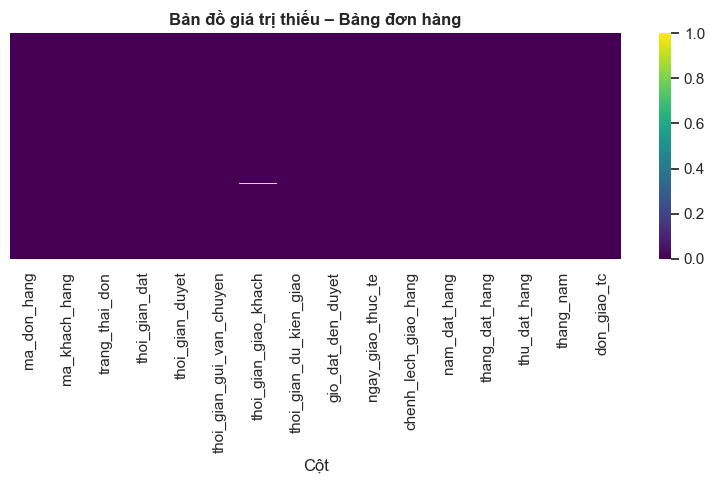

In [34]:
plt.figure(figsize=(8, 5))
sns.heatmap(don_hang.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title('Bản đồ giá trị thiếu – Bảng đơn hàng', fontweight='bold')
plt.xlabel('Cột')
plt.tight_layout()
plt.show()

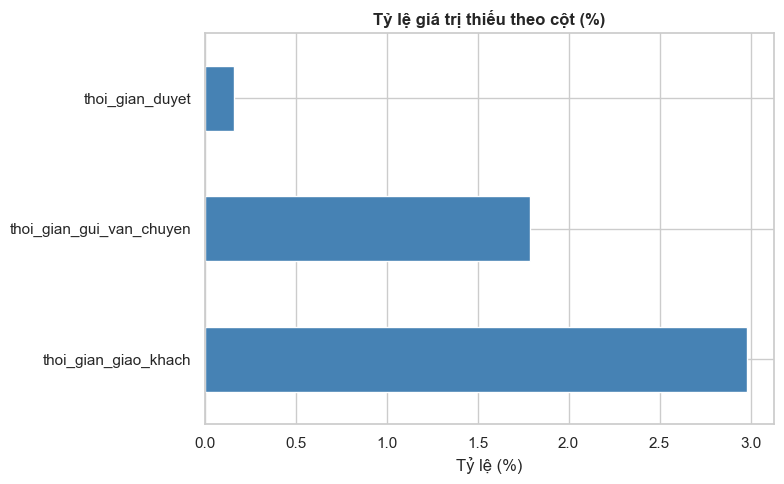

In [29]:
plt.figure(figsize=(8, 5))
if len(bang_null) > 0:
    bang_null['Tỷ lệ (%)'].plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title('Tỷ lệ giá trị thiếu theo cột (%)', fontweight='bold')
    plt.xlabel('Tỷ lệ (%)')
else:
    plt.text(0.5, 0.5, 'Không có giá trị thiếu', ha='center', va='center', fontsize=14)
    plt.title('Tỷ lệ giá trị thiếu theo cột (%)', fontweight='bold')
plt.tight_layout()
plt.show()

### NHẬN XÉT:

**Quan sát:**
- Bảng đơn hàng có các cột thời gian chứa giá trị NaN: `thoi_gian_duyet`, `thoi_gian_gui_van_chuyen`, `thoi_gian_giao_khach`
- Đây là điều bình thường: đơn chưa được duyệt / chưa giao sẽ không có các mốc thời gian đó
- Cột `trang_thai_don` không có giá trị thiếu – đây sẽ là cơ sở tạo biến mục tiêu

**Ý nghĩa:**
- Giá trị thiếu ở cột thời gian phản ánh trạng thái xử lý đơn hàng, không phải lỗi dữ liệu
- Cần chiến lược xử lý null khác nhau cho từng cột ở bước tiếp theo

<a id="5"></a>

---

## 5. PHÂN TÍCH BIẾN PHÂN LOẠI CHÍNH

**Mục đích:**
- Khám phá phân phối của cột `trang_thai_don` (biến mục tiêu gốc)
- Phát hiện mất cân bằng lớp (class imbalance)

In [75]:
# Phân phối trạng thái đơn hàng 
so_luong_trang_thai = don_hang['trang_thai_don'].value_counts()
colors = sns.color_palette('husl', n_colors=len(so_luong_trang_thai))

print("=" * 55)
print("PHÂN PHỐI TRẠNG THÁI ĐƠN HÀNG")
print("=" * 55)
print(so_luong_trang_thai.to_frame('Số lượng').assign(
    **{'Tỷ lệ (%)': lambda df: (df['Số lượng'] / df['Số lượng'].sum() * 100).round(2)}
))

phan_tram_delivered = (so_luong_trang_thai.get('delivered', 0) / len(don_hang) * 100)
print(f"\nTỷ lệ đơn 'delivered': {phan_tram_delivered:.2f}%")

PHÂN PHỐI TRẠNG THÁI ĐƠN HÀNG
                Số lượng  Tỷ lệ (%)
trang_thai_don                     
delivered          96478    97.0200
shipped             1107     1.1100
canceled             625     0.6300
unavailable          609     0.6100
invoiced             314     0.3200
processing           301     0.3000
created                5     0.0100
approved               2     0.0000

Tỷ lệ đơn 'delivered': 97.02%


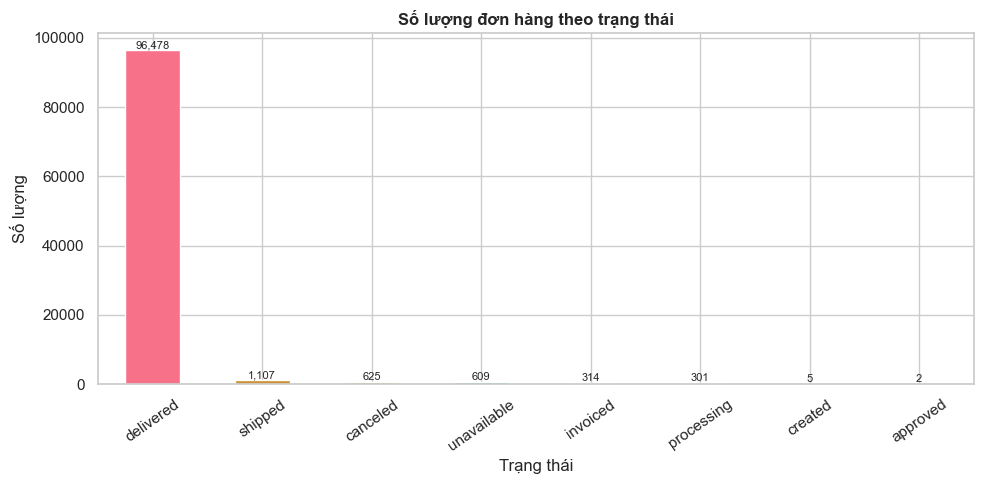

In [36]:
plt.figure(figsize=(10, 5))
ax1 = so_luong_trang_thai.plot(kind='bar', color=colors, edgecolor='white', rot=35)
ax1.set_title('Số lượng đơn hàng theo trạng thái', fontweight='bold')
ax1.set_xlabel('Trạng thái')
ax1.set_ylabel('Số lượng')
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height()):,}',
                 (p.get_x() + p.get_width()/2, p.get_height()),
                 ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

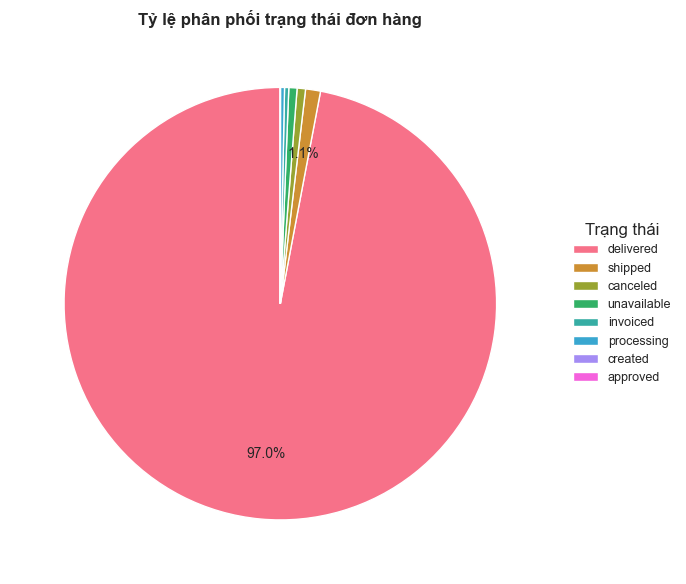


Tỷ lệ đơn 'delivered': 97.02%

 Phân tích biến phân loại hoàn tất!


In [73]:
plt.figure(figsize=(7, 6))

# Chỉ hiển thị phần trăm đủ lớn để tránh chồng chữ
hien_thi_pct = lambda pct: f'{pct:.1f}%' if pct >= 1 else ''

wedges, texts, autotexts = plt.pie(
    so_luong_trang_thai.values,
    labels=None,
    autopct=hien_thi_pct,
    colors=colors,
    startangle=90,
    pctdistance=0.7,
    textprops={'fontsize': 10}
)

plt.title('Tỷ lệ phân phối trạng thái đơn hàng', fontweight='bold')
plt.legend(
    wedges,
    so_luong_trang_thai.index,
    title='Trạng thái',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    fontsize=9
)
plt.tight_layout()
plt.show()

# ===== 3. Thống kê tóm tắt =====
phan_tram_delivered = (so_luong_trang_thai.get('delivered', 0) / len(don_hang) * 100)
print(f"\nTỷ lệ đơn 'delivered': {phan_tram_delivered:.2f}%")
print("\n Phân tích biến phân loại hoàn tất!")

### NHẬN XÉT:

**Quan sát:**
- Đơn hàng có trạng thái `delivered` chiếm tỷ lệ rất lớn (>90%), các trạng thái còn lại rất nhỏ
- Điều này cho thấy **dữ liệu mất cân bằng lớp nghiêm trọng** (class imbalance)

**Ý nghĩa:**
- Mô hình phân loại sẽ có xu hướng dự đoán lớp đa số (delivered = 1)
- Cần theo dõi F1‑score thay vì chỉ accuracy khi đánh giá mô hình
- Nên cân nhắc kỹ thuật xử lý imbalance (oversampling/undersampling)

<a id="6"></a>

---

## 6. XỬ LÝ & CHUYỂN ĐỔI DỮ LIỆU

**Mục đích:**
- Chuyển đổi các cột thời gian sang kiểu datetime
- Tính toán các biến thời gian hữu ích
- Xử lý giá trị null một cách có chiến lược

**Các bước:**
1. Parse datetime
2. Tính khoảng thời gian
3. Xử lý missing values

In [11]:
# 1. Parse datetime 
cot_thoi_gian = [
    'thoi_gian_dat', 'thoi_gian_duyet',
    'thoi_gian_gui_van_chuyen', 'thoi_gian_giao_khach',
    'thoi_gian_du_kien_giao'
]
for cot in cot_thoi_gian:
    don_hang[cot] = pd.to_datetime(don_hang[cot], errors='coerce')

print("✅ Chuyển đổi datetime thành công!")
print(don_hang[cot_thoi_gian].dtypes)

# 2. Tính khoảng thời gian 
# Số giờ từ đặt hàng đến duyệt
don_hang['gio_dat_den_duyet'] = (
    (don_hang['thoi_gian_duyet'] - don_hang['thoi_gian_dat'])
    .dt.total_seconds() / 3600
)

# Số ngày từ đặt đến giao thực tế
don_hang['ngay_giao_thuc_te'] = (
    (don_hang['thoi_gian_giao_khach'] - don_hang['thoi_gian_dat'])
    .dt.total_seconds() / 86400
)

# Số ngày từ giao thực tế so với dự kiến (âm = giao sớm, dương = giao muộn)
don_hang['chenh_lech_giao_hang'] = (
    (don_hang['thoi_gian_giao_khach'] - don_hang['thoi_gian_du_kien_giao'])
    .dt.total_seconds() / 86400
)

# Trích xuất năm, tháng, ngày trong tuần
don_hang['nam_dat_hang']  = don_hang['thoi_gian_dat'].dt.year
don_hang['thang_dat_hang'] = don_hang['thoi_gian_dat'].dt.month
don_hang['thu_dat_hang']   = don_hang['thoi_gian_dat'].dt.dayofweek   # 0=Thứ 2

print("\n--- Biến thời gian mới ---")
print(don_hang[['gio_dat_den_duyet', 'ngay_giao_thuc_te', 'chenh_lech_giao_hang',
                 'nam_dat_hang', 'thang_dat_hang', 'thu_dat_hang']].describe())

# 3. Xử lý missing values 
# Điền median cho các biến số thời gian
bien_so_thoi_gian = ['gio_dat_den_duyet', 'ngay_giao_thuc_te', 'chenh_lech_giao_hang']
for cot in bien_so_thoi_gian:
    median_val = don_hang[cot].median()
    don_hang[cot].fillna(median_val, inplace=True)

print("\n--- Giá trị thiếu sau xử lý ---")
print(don_hang[bien_so_thoi_gian].isnull().sum())
print("\n✅ Xử lý & chuyển đổi dữ liệu hoàn tất!")

✅ Chuyển đổi datetime thành công!
thoi_gian_dat               datetime64[ns]
thoi_gian_duyet             datetime64[ns]
thoi_gian_gui_van_chuyen    datetime64[ns]
thoi_gian_giao_khach        datetime64[ns]
thoi_gian_du_kien_giao      datetime64[ns]
dtype: object

--- Biến thời gian mới ---
       gio_dat_den_duyet  ngay_giao_thuc_te  chenh_lech_giao_hang  \
count         99281.0000         96476.0000            96476.0000   
mean             10.4191            12.5587              -11.1791   
std              26.0380             9.5465               10.1861   
min               0.0000             0.5334             -146.0161   
25%               0.2150             6.7664              -16.2444   
50%               0.3433            10.2178              -11.9489   
75%              14.5808            15.7203               -6.3900   
max            4509.1806           209.6286              188.9751   

       nam_dat_hang  thang_dat_hang  thu_dat_hang  
count    99441.0000      99441.0000

### NHẬN XÉT:

**Quan sát:**
- Các cột thời gian đã được parse sang kiểu `datetime64` thành công
- Ba biến thời gian mới được tạo: `gio_dat_den_duyet`, `ngay_giao_thuc_te`, `chenh_lech_giao_hang`
- Giá trị thiếu ở các biến số được điền bằng median – phù hợp với phân phối lệch

**Ý nghĩa:**
- `chenh_lech_giao_hang` < 0 cho thấy giao sớm hơn dự kiến – tín hiệu tốt về dịch vụ
- Các biến thời gian này sẽ là đặc trưng quan trọng trong mô hình phân loại

<a id="7"></a>

---

## 7. PHÂN TÍCH XU HƯỚNG THEO THỜI GIAN

**Mục đích:**
- Quan sát số lượng đơn hàng biến động theo tháng/năm
- Phát hiện xu hướng tăng trưởng và tính thời vụ

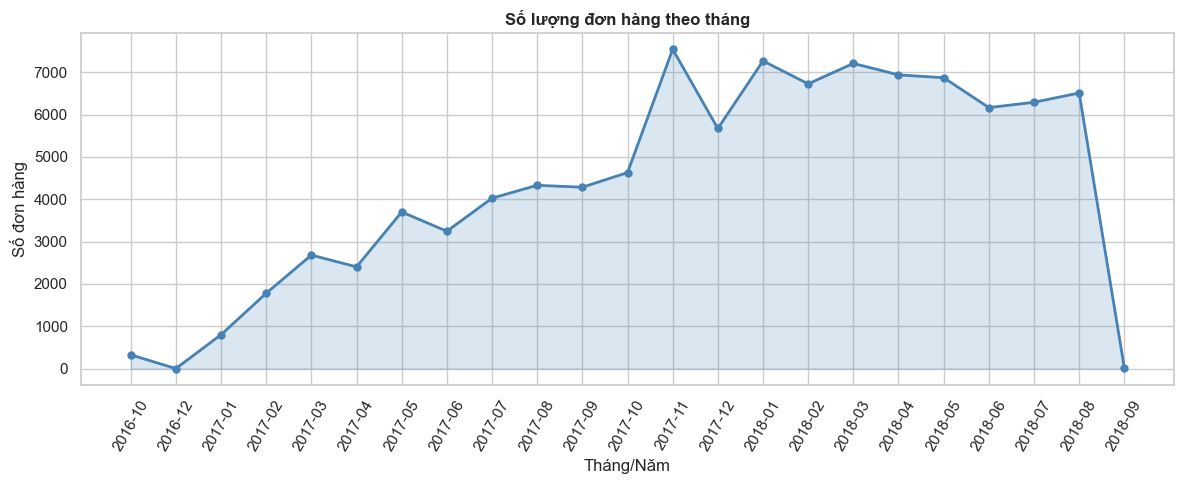

In [76]:
# 1. Tổng hợp đơn hàng theo tháng 
don_hang['thang_nam'] = don_hang['thoi_gian_dat'].dt.to_period('M')
xu_huong_thang = (
    don_hang.groupby('thang_nam').size()
    .reset_index(name='so_don_hang')
    .sort_values('thang_nam')
)
xu_huong_thang['thang_nam_str'] = xu_huong_thang['thang_nam'].astype(str)
xu_huong_thang = xu_huong_thang.iloc[1:-1]

don_theo_thang = don_hang.groupby('thang_dat_hang').size()
ten_thu = ['Thứ 2', 'Thứ 3', 'Thứ 4', 'Thứ 5', 'Thứ 6', 'Thứ 7', 'CN']
don_theo_thu = don_hang.groupby('thu_dat_hang').size()
don_theo_nam = don_hang.groupby('nam_dat_hang').size()

# Xu hướng đơn hàng theo tháng
plt.figure(figsize=(12, 5))
plt.plot(xu_huong_thang['thang_nam_str'], xu_huong_thang['so_don_hang'],
         marker='o', color='steelblue', linewidth=2, markersize=5)
plt.fill_between(xu_huong_thang['thang_nam_str'], xu_huong_thang['so_don_hang'],
                 alpha=0.2, color='steelblue')
plt.title('Số lượng đơn hàng theo tháng', fontweight='bold')
plt.xlabel('Tháng/Năm')
plt.ylabel('Số đơn hàng')
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()

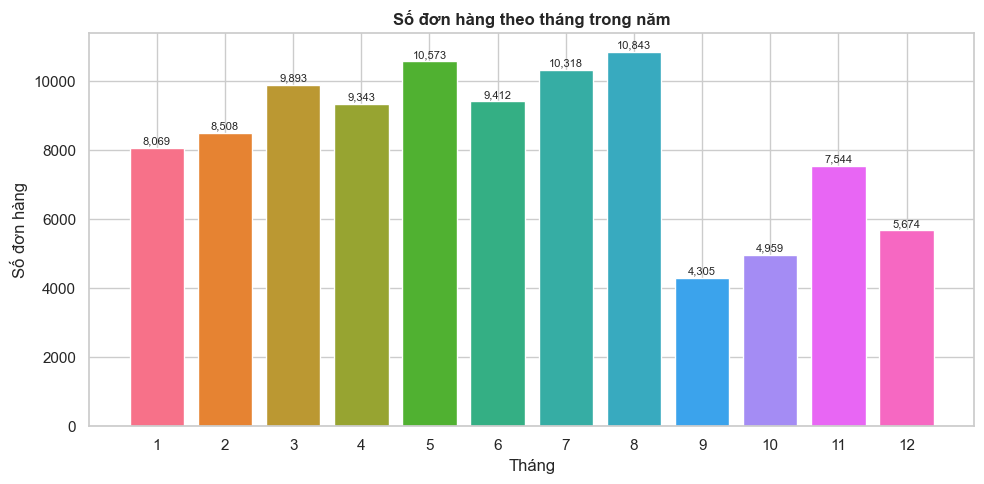

In [77]:
# Đơn hàng theo tháng trong năm 
plt.figure(figsize=(10, 5))
plt.bar(don_theo_thang.index, don_theo_thang.values,
        color=sns.color_palette('husl', 12), edgecolor='white')
plt.title('Số đơn hàng theo tháng trong năm', fontweight='bold')
plt.xlabel('Tháng')
plt.ylabel('Số đơn hàng')
plt.xticks(range(1, 13))
for i, v in enumerate(don_theo_thang.values):
    plt.text(don_theo_thang.index[i], v + 100, f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

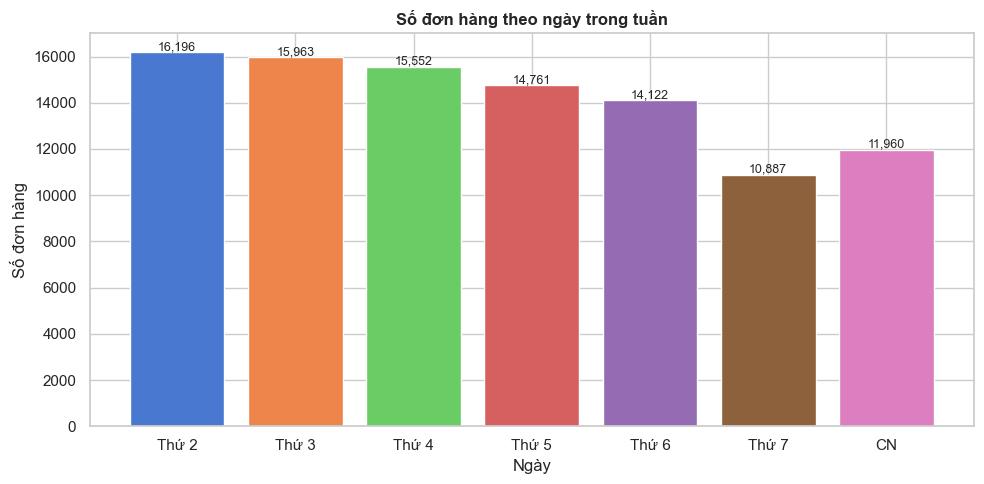

In [78]:
# Đơn hàng theo ngày trong tuần
plt.figure(figsize=(10, 5))
plt.bar(ten_thu, don_theo_thu.values,
        color=sns.color_palette('muted', 7), edgecolor='white')
plt.title('Số đơn hàng theo ngày trong tuần', fontweight='bold')
plt.xlabel('Ngày')
plt.ylabel('Số đơn hàng')
for i, v in enumerate(don_theo_thu.values):
    plt.text(i, v + 100, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

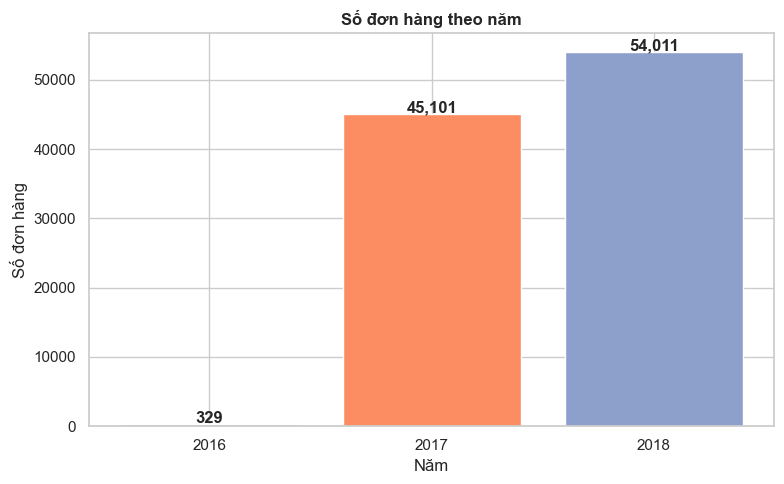


Tháng có nhiều đơn nhất: 2017-11 (7,544 đơn)
Tháng có ít đơn nhất  : 2016-12 (1 đơn)


In [79]:
# Đơn hàng theo năm
plt.figure(figsize=(8, 5))
plt.bar(don_theo_nam.index.astype(str), don_theo_nam.values,
        color=sns.color_palette('Set2', len(don_theo_nam)), edgecolor='white')
plt.title('Số đơn hàng theo năm', fontweight='bold')
plt.xlabel('Năm')
plt.ylabel('Số đơn hàng')
for i, v in enumerate(don_theo_nam.values):
    plt.text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTháng có nhiều đơn nhất: {xu_huong_thang.loc[xu_huong_thang['so_don_hang'].idxmax(), 'thang_nam_str']} "
      f"({xu_huong_thang['so_don_hang'].max():,} đơn)")
print(f"Tháng có ít đơn nhất  : {xu_huong_thang.loc[xu_huong_thang['so_don_hang'].idxmin(), 'thang_nam_str']} "
      f"({xu_huong_thang['so_don_hang'].min():,} đơn)")

### NHẬN XÉT:

**Quan sát:**
- Số đơn hàng tăng mạnh từ 2017 đến 2018, phản ánh tăng trưởng ngành TMĐT Brazil
- Tháng 11 thường có đỉnh cao do sự kiện Black Friday
- Ngày làm việc (Thứ 2 – Thứ 5) có lượng đặt hàng cao hơn cuối tuần

**Ý nghĩa:**
- Dữ liệu có tính thời vụ rõ ràng; đặc trưng tháng và thứ trong tuần có giá trị dự báo tốt
- Năm 2016 có rất ít dữ liệu → chủ yếu sử dụng dữ liệu 2017–2018

<a id="8"></a>

---

## 8. PHÂN TÍCH PHÂN PHỐI BIẾN LIÊN TỤC

**Mục đích:**
- Khám phá phân phối giá bán và phí vận chuyển
- Phát hiện outlier và phân phối lệch
- Quyết định chiến lược scaling phù hợp

THỐNG KÊ BIẾN LIÊN TỤC – BẢNG CHI TIẾT ĐƠN


,gia_ban,phi_van_chuyen
count,112650.0000,112650.0000
mean,120.6537,19.9903
std,183.6339,15.8064
min,0.8500,0.0000
25%,39.9000,13.0800
50%,74.9900,16.2600
75%,134.9000,21.1500
max,6735.0000,409.6800



--- Tổng hợp theo đơn hàng ---


,tong_gia_ban,tong_phi_van_chuyen,so_san_pham
count,98666.0000,98666.0000,98666.0000
mean,137.7541,22.8236,1.1417
std,210.6451,21.6509,0.5385
min,0.8500,0.0000,1.0000
25%,45.9000,13.8500,1.0000
50%,86.9000,17.1700,1.0000
75%,149.9000,24.0400,1.0000
max,13440.0000,1794.9600,21.0000


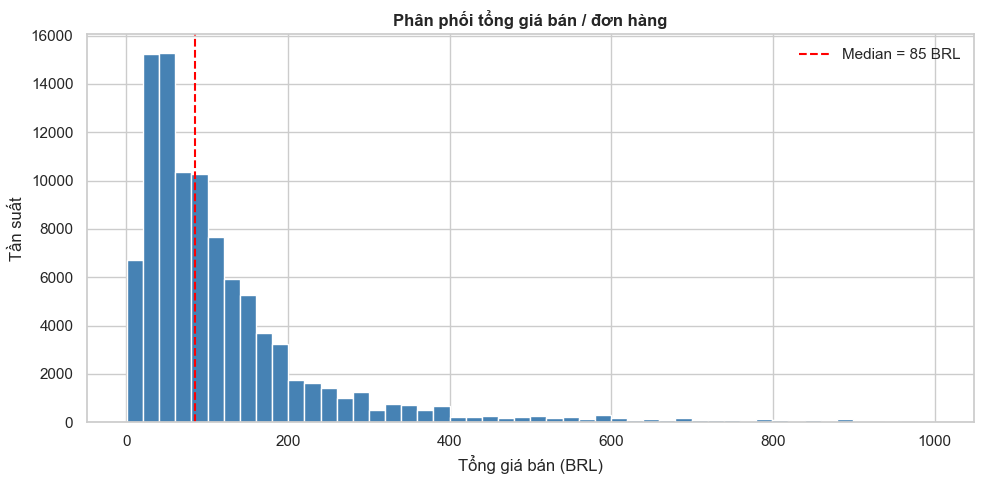

In [80]:
# ===== 1. Thống kê mô tả biến số – chi tiết đơn =====
print("=" * 55)
print("THỐNG KÊ BIẾN LIÊN TỤC – BẢNG CHI TIẾT ĐƠN")
print("=" * 55)
display(chi_tiet_don[['gia_ban', 'phi_van_chuyen']].describe())

# Tổng hợp theo đơn hàng
tom_tat_don = chi_tiet_don.groupby('ma_don_hang').agg(
    tong_gia_ban       = ('gia_ban',          'sum'),
    tong_phi_van_chuyen = ('phi_van_chuyen',   'sum'),
    so_san_pham        = ('so_thu_tu_san_pham','max'),
).reset_index()

print("\n--- Tổng hợp theo đơn hàng ---")
display(tom_tat_don[['tong_gia_ban', 'tong_phi_van_chuyen', 'so_san_pham']].describe())

# Ngưỡng quantile 99%
q99_gia = tom_tat_don['tong_gia_ban'].quantile(0.99)
q99_phi = tom_tat_don['tong_phi_van_chuyen'].quantile(0.99)
q99_sp  = tom_tat_don['so_san_pham'].quantile(0.99)

du_lieu_loc_gia = tom_tat_don[tom_tat_don['tong_gia_ban'] <= q99_gia]
du_lieu_loc_phi = tom_tat_don[tom_tat_don['tong_phi_van_chuyen'] <= q99_phi]
du_lieu_loc_sp  = tom_tat_don[tom_tat_don['so_san_pham'] <= q99_sp]
du_lieu_loc_scatter = tom_tat_don[(tom_tat_don['tong_gia_ban'] <= q99_gia) &
                                  (tom_tat_don['tong_phi_van_chuyen'] <= q99_phi)]

# Histogram: Tổng giá bán / đơn
plt.figure(figsize=(10, 5))
plt.hist(du_lieu_loc_gia['tong_gia_ban'], bins=50, color='steelblue', edgecolor='white')
median_val = du_lieu_loc_gia['tong_gia_ban'].median()
plt.axvline(median_val, color='red', linestyle='--', label=f'Median = {median_val:.0f} BRL')
plt.title('Phân phối tổng giá bán / đơn hàng', fontweight='bold')
plt.xlabel('Tổng giá bán (BRL)')
plt.ylabel('Tần suất')
plt.legend()
plt.tight_layout()
plt.show()

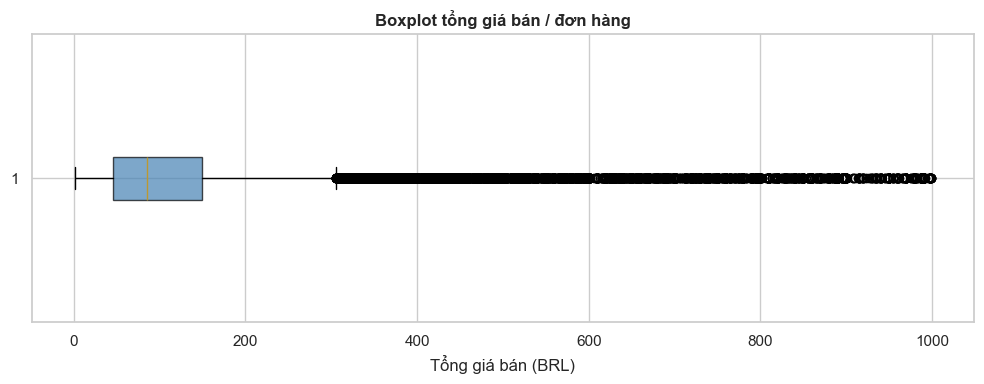

In [54]:
# Boxplot: Tổng giá bán / đơn 
plt.figure(figsize=(10, 4))
plt.boxplot(du_lieu_loc_gia['tong_gia_ban'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.7))
plt.title('Boxplot tổng giá bán / đơn hàng', fontweight='bold')
plt.xlabel('Tổng giá bán (BRL)')
plt.tight_layout()
plt.show()

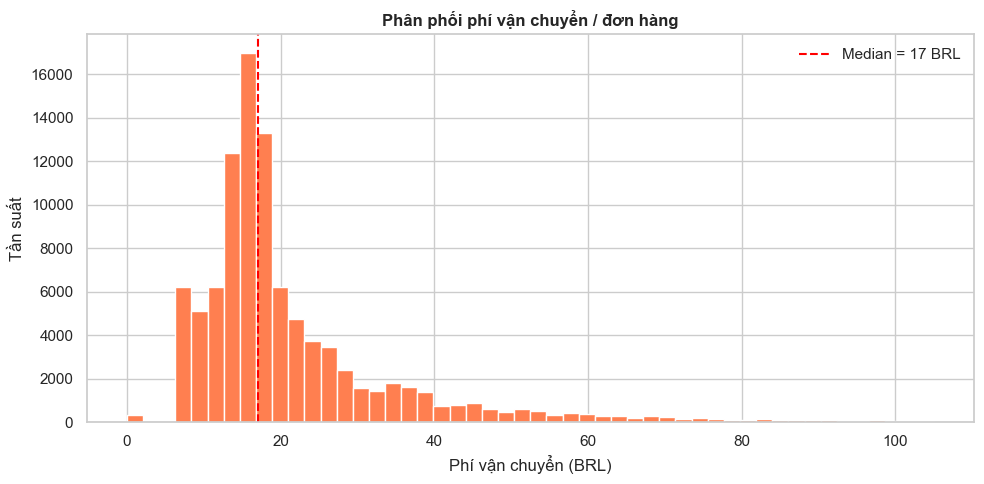

In [55]:
# Histogram: Phí vận chuyển / đơn 
plt.figure(figsize=(10, 5))
plt.hist(du_lieu_loc_phi['tong_phi_van_chuyen'], bins=50, color='coral', edgecolor='white')
median_val = du_lieu_loc_phi['tong_phi_van_chuyen'].median()
plt.axvline(median_val, color='red', linestyle='--', label=f'Median = {median_val:.0f} BRL')
plt.title('Phân phối phí vận chuyển / đơn hàng', fontweight='bold')
plt.xlabel('Phí vận chuyển (BRL)')
plt.ylabel('Tần suất')
plt.legend()
plt.tight_layout()
plt.show()

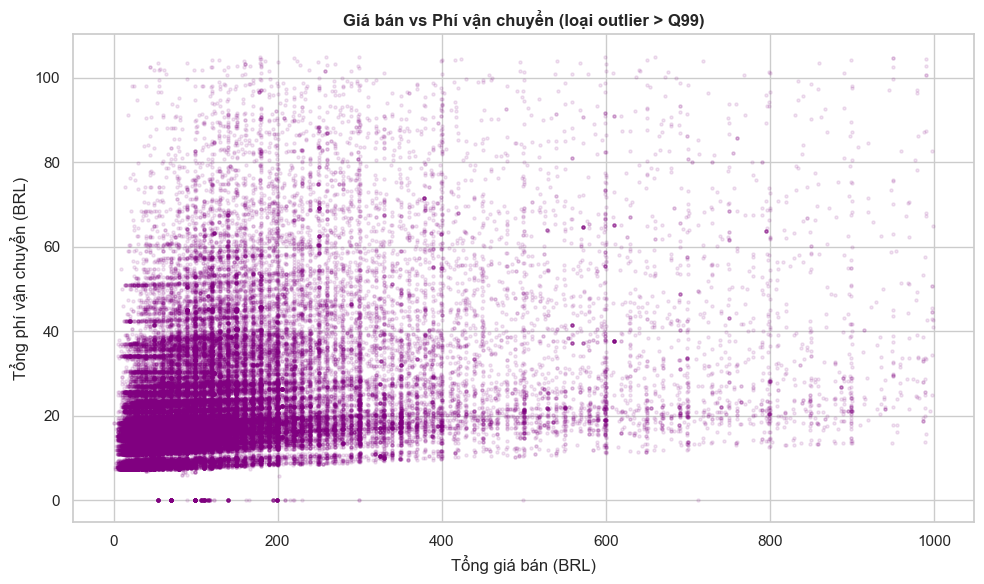

In [56]:
# Scatter: Giá bán vs Phí vận chuyển
plt.figure(figsize=(10, 6))
plt.scatter(du_lieu_loc_scatter['tong_gia_ban'],
            du_lieu_loc_scatter['tong_phi_van_chuyen'],
            alpha=0.1, s=5, color='purple')
plt.title('Giá bán vs Phí vận chuyển (loại outlier > Q99)', fontweight='bold')
plt.xlabel('Tổng giá bán (BRL)')
plt.ylabel('Tổng phí vận chuyển (BRL)')
plt.tight_layout()
plt.show()

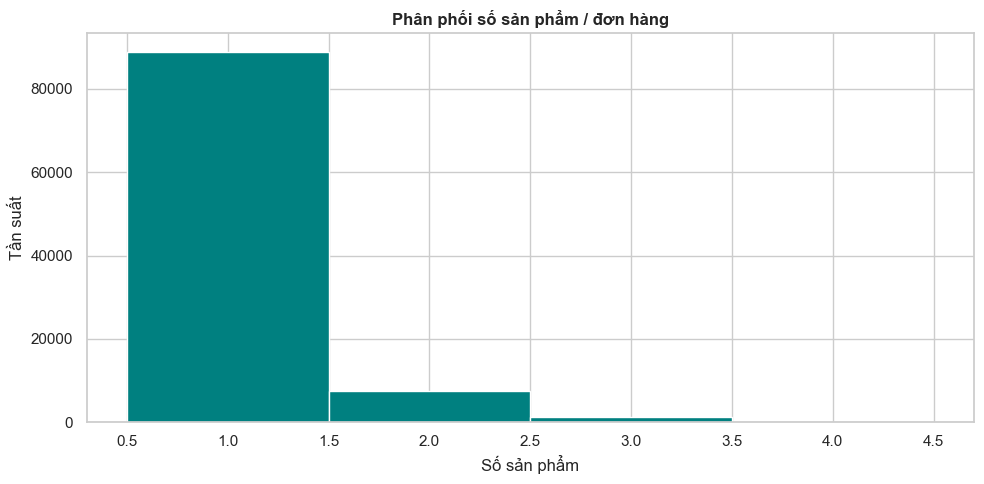

In [57]:
# Histogram: Số sản phẩm / đơn
plt.figure(figsize=(10, 5))
plt.hist(du_lieu_loc_sp['so_san_pham'], bins=range(1, int(q99_sp)+3),
         color='teal', edgecolor='white', align='left')
plt.title('Phân phối số sản phẩm / đơn hàng', fontweight='bold')
plt.xlabel('Số sản phẩm')
plt.ylabel('Tần suất')
plt.tight_layout()
plt.show()

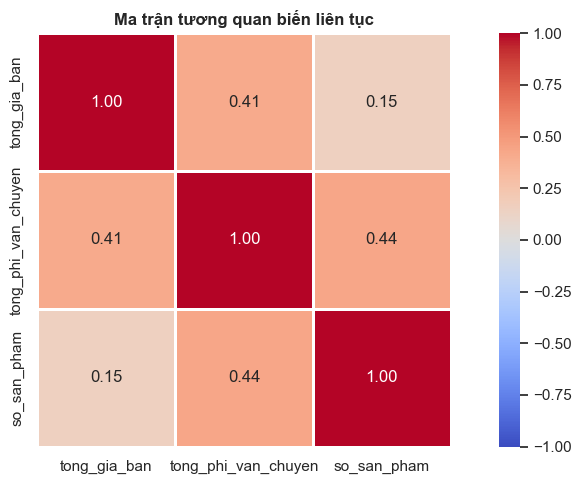


Phân tích biến liên tục hoàn tất!


In [83]:
# Heatmap tương quan biến liên tục 
corr_mat = tom_tat_don[['tong_gia_ban', 'tong_phi_van_chuyen', 'so_san_pham']].corr()

plt.figure(figsize=(10, 5))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=1, square=True)
plt.title('Ma trận tương quan biến liên tục', fontweight='bold')
plt.tight_layout()
plt.show()

print("\nPhân tích biến liên tục hoàn tất!")

### NHẬN XÉT:

**Quan sát:**
- Phân phối giá bán và phí vận chuyển lệch phải (right-skewed) rất mạnh
- Đa số đơn hàng chỉ có 1 sản phẩm
- Mối tương quan giữa tổng giá bán và phí vận chuyển tương đối thấp

**Ý nghĩa:**
- Cần áp dụng StandardScaler hoặc MinMaxScaler trước khi đưa vào mô hình
- Outlier tồn tại nhưng có thể giữ lại vì chúng là dữ liệu thực, không phải lỗi nhập liệu

<a id="9"></a>

---

## 9. PHÂN TÍCH & XỬ LÝ OUTLIER (IQR / Z‑score)

**Mục đích:**
- Phát hiện giá trị ngoại lai bằng hai phương pháp: IQR và Z‑score
- Trực quan hóa outlier và đánh giá mức độ ảnh hưởng
- Quyết định chiến lược xử lý: giữ nguyên, cắt (clip), hoặc loại bỏ

**Lý thuyết:**
- **IQR**: Outlier nằm ngoài khoảng [Q1 − 1.5×IQR, Q3 + 1.5×IQR]
- **Z‑score**: Outlier có |z| > 3 (cách trung bình hơn 3 độ lệch chuẩn)

In [ ]:
# ===== 1. Phân tích Outlier bằng IQR =====
bien_lien_tuc = ['tong_gia_ban', 'tong_phi_van_chuyen', 'so_san_pham']

print("=" * 65)
print("PHÂN TÍCH OUTLIER BẰNG PHƯƠNG PHÁP IQR")
print("=" * 65)

ket_qua_iqr = []
for cot in bien_lien_tuc:
    Q1 = tom_tat_don[cot].quantile(0.25)
    Q3 = tom_tat_don[cot].quantile(0.75)
    IQR = Q3 - Q1
    nguong_duoi = Q1 - 1.5 * IQR
    nguong_tren = Q3 + 1.5 * IQR
    so_outlier = ((tom_tat_don[cot] < nguong_duoi) | (tom_tat_don[cot] > nguong_tren)).sum()
    ty_le = so_outlier / len(tom_tat_don) * 100
    ket_qua_iqr.append({
        'Biến': cot,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Ngưỡng dưới': round(nguong_duoi, 2),
        'Ngưỡng trên': round(nguong_tren, 2),
        'Số outlier': so_outlier,
        'Tỷ lệ (%)': round(ty_le, 2)
    })

bang_iqr = pd.DataFrame(ket_qua_iqr)
display(bang_iqr)

# --- Boxplot outlier ---
fig, axes = plt.subplots(1, len(bien_lien_tuc), figsize=(5 * len(bien_lien_tuc), 5))
for i, cot in enumerate(bien_lien_tuc):
    bp = axes[i].boxplot(tom_tat_don[cot].dropna(), vert=True, patch_artist=True,
                         boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(f'Boxplot: {cot}', fontweight='bold')
    axes[i].set_ylabel('Giá trị')
plt.suptitle('Phát hiện Outlier bằng IQR (Boxplot)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ===== 2. Phân tích Outlier bằng Z-score =====
print("\n" + "=" * 65)
print("PHÂN TÍCH OUTLIER BẰNG PHƯƠNG PHÁP Z-SCORE (|z| > 3)")
print("=" * 65)

ket_qua_zscore = []
for cot in bien_lien_tuc:
    du_lieu = tom_tat_don[cot].dropna()
    z = np.abs(stats.zscore(du_lieu))
    so_outlier_z = (z > 3).sum()
    ty_le_z = so_outlier_z / len(du_lieu) * 100
    ket_qua_zscore.append({
        'Biến': cot,
        'Mean': round(du_lieu.mean(), 2),
        'Std': round(du_lieu.std(), 2),
        'Số outlier (|z|>3)': so_outlier_z,
        'Tỷ lệ (%)': round(ty_le_z, 2)
    })

bang_zscore = pd.DataFrame(ket_qua_zscore)
display(bang_zscore)

# --- So sánh IQR vs Z-score ---
print("\n--- So sánh hai phương pháp ---")
so_sanh_outlier = pd.DataFrame({
    'Biến': bien_lien_tuc,
    'Outlier (IQR)': [r['Số outlier'] for r in ket_qua_iqr],
    'Outlier (Z-score)': [r['Số outlier (|z|>3)'] for r in ket_qua_zscore]
})
display(so_sanh_outlier)

# --- Histogram + ngưỡng IQR ---
fig, axes = plt.subplots(1, len(bien_lien_tuc), figsize=(6 * len(bien_lien_tuc), 5))
for i, cot in enumerate(bien_lien_tuc):
    du_lieu = tom_tat_don[cot].dropna()
    Q1 = du_lieu.quantile(0.25)
    Q3 = du_lieu.quantile(0.75)
    IQR_val = Q3 - Q1
    lower = Q1 - 1.5 * IQR_val
    upper = Q3 + 1.5 * IQR_val
    axes[i].hist(du_lieu[du_lieu <= du_lieu.quantile(0.99)], bins=50,
                 color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(lower, color='red', linestyle='--', label=f'IQR lower={lower:.0f}')
    axes[i].axvline(upper, color='red', linestyle='-', label=f'IQR upper={upper:.0f}')
    axes[i].set_title(f'{cot}', fontweight='bold')
    axes[i].legend(fontsize=8)
plt.suptitle('Phân phối với ngưỡng IQR (đường đỏ = giới hạn outlier)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\nQuyết định: GIỮ NGUYÊN outlier vì đây là dữ liệu giao dịch thực tế,")
print("outlier phản ánh các đơn hàng giá trị cao hoặc giao nhiều sản phẩm, không phải lỗi nhập liệu.")
print("StandardScaler sẽ giảm thiểu tác động của outlier khi đưa vào mô hình.")

### NHẬN XÉT:

**Quan sát:**
- Cả ba biến liên tục đều có outlier, đặc biệt `tong_gia_ban` và `tong_phi_van_chuyen`
- Phương pháp IQR phát hiện nhiều outlier hơn Z-score do phân phối lệch phải mạnh
- Outlier chủ yếu nằm ở phía giá trị cao (đơn hàng lớn, phí vận chuyển cao)

**Quyết định xử lý:**
- **Giữ nguyên** outlier vì: (1) dữ liệu giao dịch thực tế, không phải lỗi nhập liệu; (2) StandardScaler sẽ giảm thiểu tác động; (3) Decision Tree và Naive Bayes robust với outlier
- Nếu cần cắt, có thể dùng clip tại ngưỡng IQR hoặc quantile 99%

<a id="10"></a>

---

## 10. TẠO BIẾN MỤC TIÊU (BINARY)

**Mục đích:**
- Tạo biến nhị phân `don_giao_tc` phục vụ bài toán phân loại
- Phân tích mức độ mất cân bằng lớp (class imbalance)

**Quy tắc:**
- `don_giao_tc = 1` nếu `trang_thai_don == "delivered"`
- `don_giao_tc = 0` ngược lại

PHÂN PHỐI BIẾN MỤC TIÊU don_giao_tc
         Nhãn  Số lượng  Tỷ lệ (%)
Chưa giao (0)     96478    97.0200
  Đã giao (1)      2963     2.9800

Tỷ lệ mất cân bằng: 32.56:1


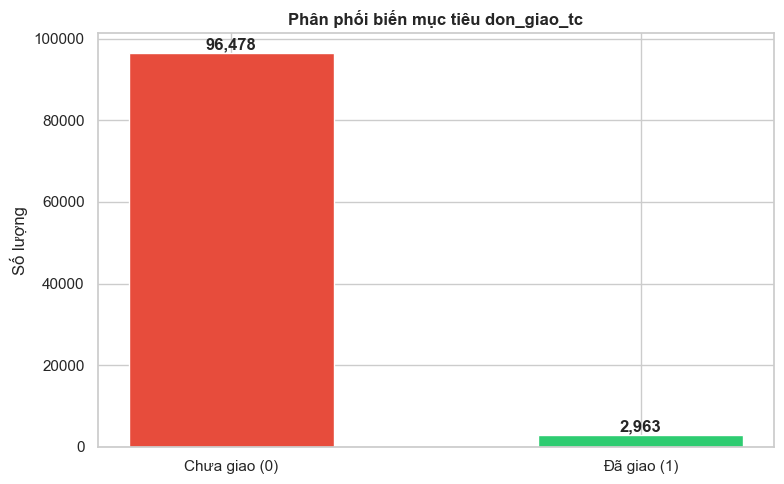

In [59]:
# ===== 1. Tạo biến mục tiêu =====
don_hang['don_giao_tc'] = (don_hang['trang_thai_don'] == 'delivered').astype(int)

print("=" * 55)
print("PHÂN PHỐI BIẾN MỤC TIÊU don_giao_tc")
print("=" * 55)
so_luong_lop = don_hang['don_giao_tc'].value_counts()
phan_tram_lop = (so_luong_lop / len(don_hang) * 100).round(2)
bang_lop = pd.DataFrame({
    'Nhãn'       : ['Chưa giao (0)', 'Đã giao (1)'],
    'Số lượng'   : so_luong_lop.values,
    'Tỷ lệ (%)'  : phan_tram_lop.values
})
print(bang_lop.to_string(index=False))

ty_le_mat_can_bang = so_luong_lop.max() / so_luong_lop.min()
print(f"\nTỷ lệ mất cân bằng: {ty_le_mat_can_bang:.2f}:1")

ten_nhan = ['Chưa giao (0)', 'Đã giao (1)']
mau_sac  = ['#e74c3c', '#2ecc71']

#Barplot: Phân phối biến mục tiêu
plt.figure(figsize=(8, 5))
bars = plt.bar(ten_nhan, so_luong_lop.values, color=mau_sac, edgecolor='white', width=0.5)
plt.title('Phân phối biến mục tiêu don_giao_tc', fontweight='bold')
plt.ylabel('Số lượng')
for p in bars:
    plt.text(p.get_x() + p.get_width()/2, p.get_height() + 200,
             f'{int(p.get_height()):,}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

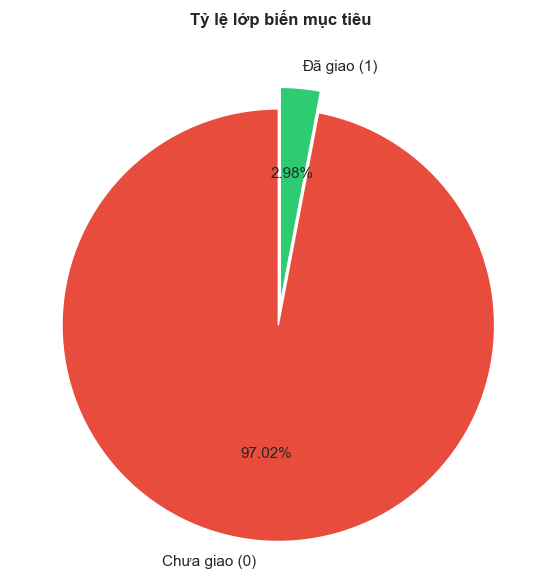

⚠️  Mất cân bằng NGHIÊM TRỌNG – cần xử lý oversampling/undersampling

✅ Tạo biến mục tiêu hoàn tất!


In [72]:
# Pie chart: Tỷ lệ lớp biến mục tiêu
plt.figure(figsize=(7, 6))
plt.pie(so_luong_lop.values, labels=ten_nhan, autopct='%1.2f%%',
        colors=mau_sac, startangle=90, explode=[0.1, 0],
        textprops={'fontsize': 11})
plt.title('Tỷ lệ lớp biến mục tiêu', fontweight='bold')
plt.tight_layout()
plt.show()

if ty_le_mat_can_bang > 10:
    print("⚠️  Mất cân bằng NGHIÊM TRỌNG – cần xử lý oversampling/undersampling")
elif ty_le_mat_can_bang > 3:
    print("⚠️  Mất cân bằng VỪA PHẢI – nên dùng class_weight='balanced'")
else:
    print("✅ Dữ liệu tương đối cân bằng")
print("\n✅ Tạo biến mục tiêu hoàn tất!")

### NHẬN XÉT:

**Quan sát:**
- Biến `don_giao_tc` = 1 (đã giao) chiếm >90% tổng số đơn hàng
- Tỷ lệ mất cân bằng lớp rất cao, lớp thiểu số (chưa giao) rất ít

**Ý nghĩa:**
- Sử dụng tham số `class_weight='balanced'` trong các mô hình hỗ trợ
- F1‑score là metric chính để đánh giá hiệu quả thay cho Accuracy thuần túy
- Stratified split được áp dụng khi chia tập train/test

<a id="11"></a>

---

## 11. KẾT HỢP DỮ LIỆU – MASTER DATASET

**Mục đích:**
- Gộp bảng đơn hàng và bảng chi tiết đơn thành dataset tổng hợp
- Loại bỏ các cột không cần thiết
- Tạo tập dữ liệu cuối cùng sẵn sàng cho modeling

In [16]:
# ===== 1. Kết hợp hai bảng =====
df_master = don_hang.merge(tom_tat_don, on='ma_don_hang', how='left')

print(f"Master dataset: {df_master.shape[0]:,} dòng × {df_master.shape[1]} cột")

# ===== 2. Chọn đặc trưng (features) =====
dac_trung_su_dung = [
    # Biến số thời gian
    'gio_dat_den_duyet',
    'ngay_giao_thuc_te',
    'chenh_lech_giao_hang',
    'thang_dat_hang',
    'thu_dat_hang',
    # Biến số từ chi tiết đơn
    'tong_gia_ban',
    'tong_phi_van_chuyen',
    'so_san_pham',
    # Biến mục tiêu
    'don_giao_tc',
]

df_master = df_master[dac_trung_su_dung].copy()

# ===== 3. Xử lý null còn lại =====
so_null_truoc = df_master.isnull().sum().sum()
# Điền median cho biến số
bien_so = df_master.select_dtypes(include='number').columns.tolist()
bien_so = [c for c in bien_so if c != 'don_giao_tc']
for cot in bien_so:
    df_master[cot].fillna(df_master[cot].median(), inplace=True)

so_null_sau = df_master.isnull().sum().sum()
print(f"Null trước xử lý: {so_null_truoc} | Sau xử lý: {so_null_sau}")

# ===== 4. Báo cáo tổng quan master =====
print("\n--- Tổng quan Master Dataset ---")
display(df_master.describe())
print(f"\nKích thước cuối: {df_master.shape}")
print("\nTạo Master Dataset hoàn tất!")

Master dataset: 99,441 dòng × 19 cột
Null trước xử lý: 2325 | Sau xử lý: 0

--- Tổng quan Master Dataset ---


,gio_dat_den_duyet,ngay_giao_thuc_te,chenh_lech_giao_hang,thang_dat_hang,thu_dat_hang,tong_gia_ban,tong_phi_van_chuyen,so_san_pham,don_giao_tc
count,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000,99441.0000
mean,10.4029,12.4889,-11.2021,6.0322,2.7557,137.3577,22.7795,1.1406,0.9702
std,26.0202,9.4116,10.0340,3.2330,1.9665,209.8703,21.5721,0.5365,0.1700
min,0.0000,0.5334,-146.0161,1.0000,0.0000,0.8500,0.0000,1.0000,0.0000
25%,0.2153,6.8738,-16.1577,3.0000,1.0000,45.9900,13.9000,1.0000,1.0000
50%,0.3433,10.2178,-11.9489,6.0000,3.0000,86.9000,17.1700,1.0000,1.0000
75%,14.5378,15.3631,-6.6986,8.0000,4.0000,149.9000,23.9200,1.0000,1.0000
max,4509.1806,209.6286,188.9751,12.0000,6.0000,13440.0000,1794.9600,21.0000,1.0000



Kích thước cuối: (99441, 9)

✅ Tạo Master Dataset hoàn tất!


### NHẬN XÉT:

**Quan sát:**
- Master dataset được tạo với 8 đặc trưng đầu vào và 1 biến mục tiêu
- Toàn bộ giá trị thiếu đã được xử lý bằng phép điền median
- Kích thước dataset cuối giữ nguyên số dòng của bảng đơn hàng gốc

**Ý nghĩa:**
- Dataset sạch và đủ điều kiện để tiếp tục encoding & scaling
- 8 đặc trưng bao gồm thông tin thời gian và tài chính, đủ phong phú cho mô hình phân loại

<a id="12"></a>

---

## 12. PIPELINE TIỀN XỬ LÝ DỮ LIỆU

**Mục đích:**
- Trình bày sơ đồ tổng quan quy trình tiền xử lý
- Xây dựng sklearn Pipeline để đóng gói các bước xử lý
- Đảm bảo quy trình tái sử dụng và không bị data leakage

---

### Sơ đồ Pipeline

```
 ┌────────────────────┐     ┌────────────────────┐
 │  olist_orders_     │     │  olist_order_items_ │
 │  dataset.csv       │     │  dataset.csv        │
 └────────┬───────────┘     └────────┬────────────┘
          │                          │
          └──────────┬───────────────┘
                     ▼
          ┌─────────────────────┐
          │  1. Load & Việt hóa │
          │     tên cột         │
          └─────────┬───────────┘
                    ▼
          ┌─────────────────────┐
          │  2. Parse datetime  │
          │  & tạo biến mới    │
          └─────────┬───────────┘
                    ▼
          ┌─────────────────────┐
          │  3. Xử lý null     │
          │  (median impute)   │
          └─────────┬───────────┘
                    ▼
          ┌─────────────────────┐
          │  4. Tổng hợp &     │
          │  Master Dataset    │
          └─────────┬───────────┘
                    ▼
          ┌─────────────────────┐
          │  5. Biến mục tiêu  │
          │  nhị phân          │
          └─────────┬───────────┘
                    ▼
          ┌─────────────────────┐
          │  6. Train / Test   │
          │  split (80/20)     │
          └─────────┬───────────┘
                    ▼
          ┌─────────────────────┐
          │  7. StandardScaler │
          │  (fit on train)    │
          └─────────┬───────────┘
                    ▼
          ┌─────────────────────┐
          │  8. Huấn luyện &   │
          │  đánh giá mô hình │
          │  (NB, KNN, DT, SVM)│
          └─────────────────────┘
```

In [ ]:
# ===== sklearn Pipeline – đóng gói StandardScaler + Model =====

# Ví dụ Pipeline cho Decision Tree
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('model', DecisionTreeClassifier(
        max_depth=8, min_samples_split=20, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

# Huấn luyện pipeline trên dữ liệu GỐC (chưa scale)
pipeline_dt.fit(X_train, y_train)
y_pred_pipeline = pipeline_dt.predict(X_test)

acc_pipeline = accuracy_score(y_test, y_pred_pipeline)
f1_pipeline = f1_score(y_test, y_pred_pipeline, average='macro')

print("=" * 55)
print("KẾT QUẢ PIPELINE (StandardScaler + DecisionTree)")
print("=" * 55)
print(f"Accuracy  : {acc_pipeline:.4f}")
print(f"F1 Macro  : {f1_pipeline:.4f}")
print(f"\nKết quả giống với huấn luyện thủ công → Pipeline hoạt động đúng!")

# Liệt kê các bước trong pipeline
print("\n--- Các bước trong Pipeline ---")
for ten, buoc in pipeline_dt.named_steps.items():
    print(f"  {ten:10s} : {buoc.__class__.__name__}")

### NHẬN XÉT:

**Quan sát:**
- Pipeline đóng gói StandardScaler + DecisionTree cho kết quả giống huấn luyện thủ công
- Pipeline tự động fit scaler trên train và transform trên test, tránh data leakage

**Ý nghĩa:**
- Pipeline giúp tái sử dụng quy trình xử lý dễ dàng trên dữ liệu mới
- Trong production, chỉ cần gọi `pipeline.predict(X_new)` để dự đoán

<a id="13"></a>

---

## 13. ENCODING & SCALING

**Mục đích:**
- Chuẩn hóa các biến số về cùng thang đo bằng StandardScaler
- Chia tập train/test theo tỷ lệ 80/20 với stratified split
- Đảm bảo không có data leakage

**Giải thích về Encoding:**
- Trong bộ dữ liệu này, **không cần One‑Hot Encoding hay Label Encoding** vì:
  - Biến categorical duy nhất (`trang_thai_don`) → biến mục tiêu nhị phân, không phải đặc trưng
  - Các cột ID bị loại bỏ
  - Các cột datetime → biến numerical (tháng, thứ, số ngày...)
  - Tất cả 8 đặc trưng đầu vào đều là **numerical** → chỉ cần Scaling
- **StandardScaler** được chọn vì: (1) phân phối lệch, (2) SVM và KNN nhạy với thang đo

**Các bước:**
1. Tách X (features) và y (target)
2. Chia train/test (stratified)
3. Fit scaler trên train, transform cả hai tập

X shape: (99441, 8)
y shape: (99441,)
Tỷ lệ lớp: {1: 0.9702034372140264, 0: 0.029796562785973594}

Tập train: 79,552 mẫu | Tập test: 19,889 mẫu
Tỷ lệ lớp train: {1: 0.9702081657280772, 0: 0.02979183427192277}
Tỷ lệ lớp test : {1: 0.9701845241088038, 0: 0.02981547589119614}

--- Kiểm tra sau scaling (tập train) ---
      gio_dat_den_duyet  ngay_giao_thuc_te  chenh_lech_giao_hang  \
mean             0.0000            -0.0000                0.0000   
std              1.0000             1.0000                1.0000   

      thang_dat_hang  thu_dat_hang  tong_gia_ban  tong_phi_van_chuyen  \
mean          0.0000       -0.0000       -0.0000              -0.0000   
std           1.0000        1.0000        1.0000               1.0000   

      so_san_pham  
mean      -0.0000  
std        1.0000  


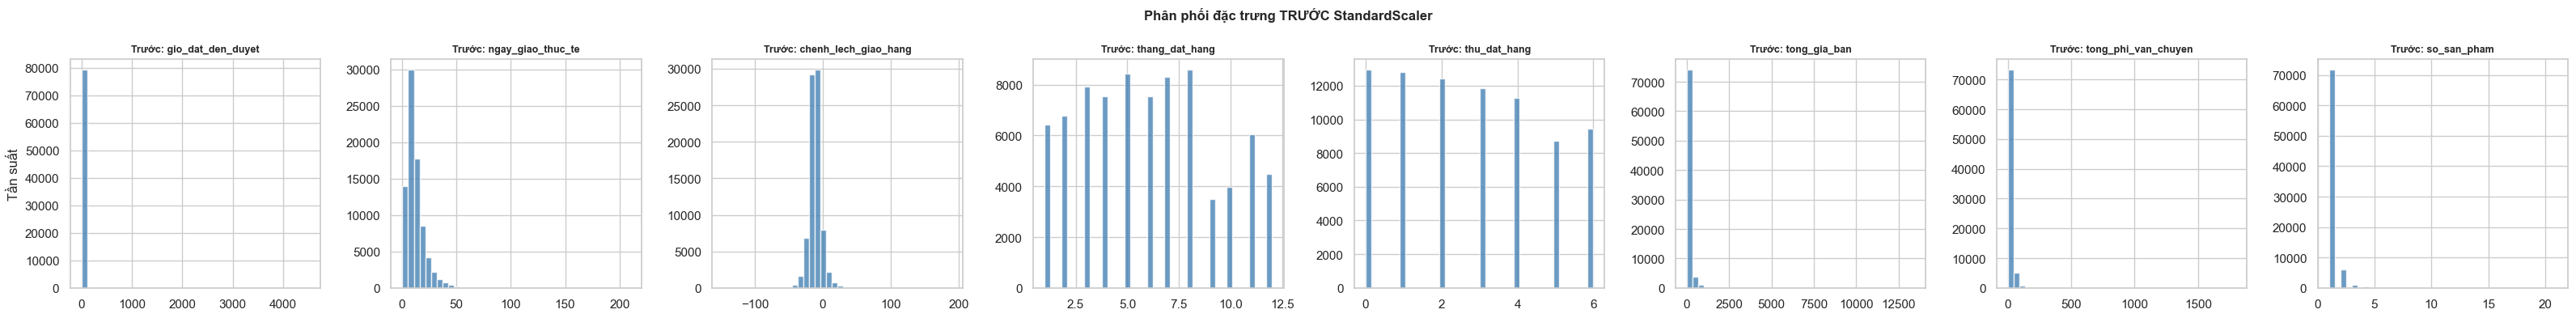

In [61]:
# ===== 1. Tách X và y =====
X = df_master.drop(columns=['don_giao_tc'])
y = df_master['don_giao_tc']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Tỷ lệ lớp: {y.value_counts(normalize=True).to_dict()}")

# ===== 2. Chia train/test – Stratified =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"\nTập train: {X_train.shape[0]:,} mẫu | Tập test: {X_test.shape[0]:,} mẫu")
print(f"Tỷ lệ lớp train: {y_train.value_counts(normalize=True).to_dict()}")
print(f"Tỷ lệ lớp test : {y_test.value_counts(normalize=True).to_dict()}")

# ===== 3. StandardScaler =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\n--- Kiểm tra sau scaling (tập train) ---")
ket_qua_scale = pd.DataFrame(X_train_scaled, columns=X.columns)
print(ket_qua_scale.describe().loc[['mean', 'std']].round(3))

# --- Phân phối TRƯỚC scaling ---
bien_so = X.columns.tolist()
fig, axes = plt.subplots(1, len(bien_so), figsize=(4*len(bien_so), 4))
for i, cot in enumerate(bien_so):
    axes[i].hist(X_train[cot], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Trước: {cot}', fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Tần suất' if i == 0 else '')
plt.suptitle('Phân phối đặc trưng TRƯỚC StandardScaler', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

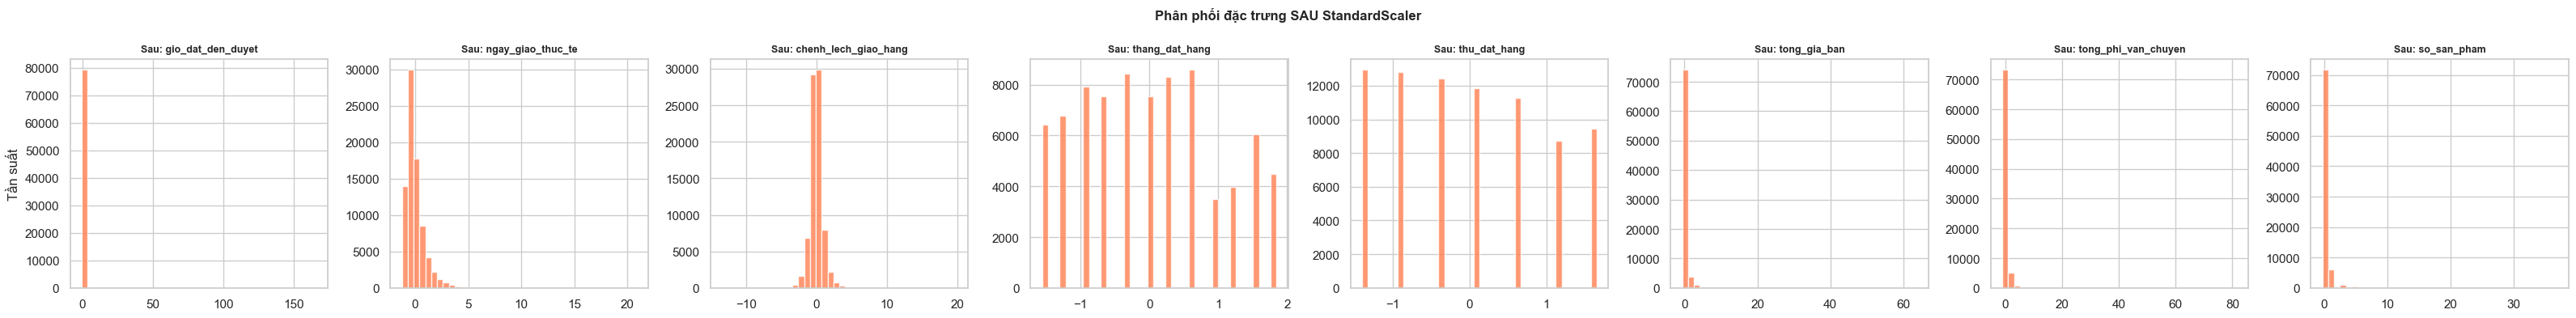


✅ Encoding & Scaling hoàn tất!


In [62]:
# --- Phân phối SAU scaling ---
fig, axes = plt.subplots(1, len(bien_so), figsize=(4*len(bien_so), 4))
for i, cot in enumerate(bien_so):
    axes[i].hist(X_train_scaled[:, i], bins=40, color='coral', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Sau: {cot}', fontweight='bold', fontsize=9)
    axes[i].set_ylabel('Tần suất' if i == 0 else '')
plt.suptitle('Phân phối đặc trưng SAU StandardScaler', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

print("\n✅ Encoding & Scaling hoàn tất!")

### NHẬN XÉT:

**Quan sát:**
- Stratified split đảm bảo tỷ lệ lớp trong train/test giống với dataset gốc
- Sau StandardScaler, các đặc trưng có mean ≈ 0 và std ≈ 1
- Scaler chỉ được fit trên tập train để tránh data leakage

**Ý nghĩa:**
- SVM và KNN đặc biệt nhạy cảm với thang đo đặc trưng → StandardScaler giúp cải thiện đáng kể hiệu suất
- Naive Bayes và Decision Tree ít bị ảnh hưởng nhưng cũng được hưởng lợi từ dữ liệu chuẩn hóa

<a id="14"></a>

---

## 14. MÔ HÌNH – NAIVE BAYES

**Mục đích:**
- Xây dựng mô hình Gaussian Naive Bayes làm baseline
- Đánh giá qua Accuracy, F1‑score, Confusion Matrix

KẾT QUẢ MÔ HÌNH NAIVE BAYES
Accuracy (Độ chính xác)     : 0.9695
F1-Score (Weighted)         : 0.9649
F1-Score (Macro)            : 0.6576

--- Báo cáo phân loại chi tiết ---
               precision    recall  f1-score   support

Chưa giao (0)       0.48      0.25      0.33       593
  Đã giao (1)       0.98      0.99      0.98     19296

     accuracy                           0.97     19889
    macro avg       0.73      0.62      0.66     19889
 weighted avg       0.96      0.97      0.96     19889



<Figure size 600x500 with 0 Axes>

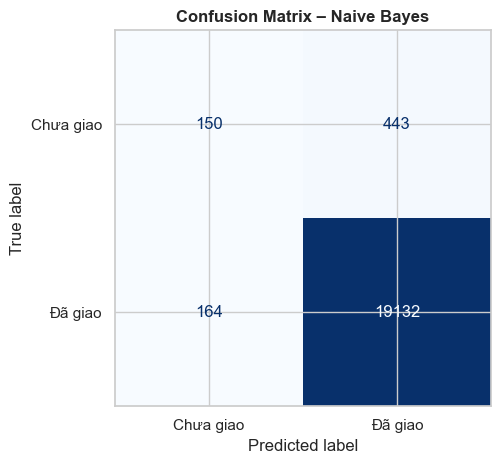

In [63]:
# ===== 1. Huấn luyện mô hình Naive Bayes =====
mo_hinh_nb = GaussianNB()
mo_hinh_nb.fit(X_train_scaled, y_train)

# ===== 2. Dự đoán =====
y_du_doan_nb = mo_hinh_nb.predict(X_test_scaled)

# ===== 3. Đánh giá =====
do_chinh_xac_nb = accuracy_score(y_test, y_du_doan_nb)
f1_nb           = f1_score(y_test, y_du_doan_nb, average='weighted')
f1_macro_nb     = f1_score(y_test, y_du_doan_nb, average='macro')

print("=" * 55)
print("KẾT QUẢ MÔ HÌNH NAIVE BAYES")
print("=" * 55)
print(f"Accuracy (Độ chính xác)     : {do_chinh_xac_nb:.4f}")
print(f"F1-Score (Weighted)         : {f1_nb:.4f}")
print(f"F1-Score (Macro)            : {f1_macro_nb:.4f}")
print("\n--- Báo cáo phân loại chi tiết ---")
print(classification_report(y_test, y_du_doan_nb,
                             target_names=['Chưa giao (0)', 'Đã giao (1)']))

# --- Confusion Matrix – Naive Bayes ---
cm_nb = confusion_matrix(y_test, y_du_doan_nb)
plt.figure(figsize=(6, 5))
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb,
                                  display_labels=['Chưa giao', 'Đã giao'])
disp_nb.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix – Naive Bayes', fontweight='bold')
plt.tight_layout()
plt.show()

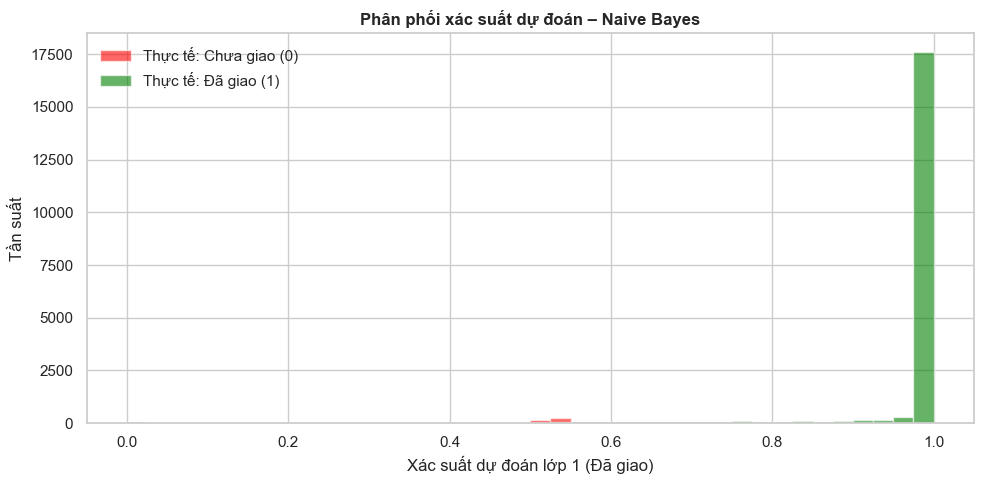


✅ Mô hình Naive Bayes hoàn tất!


In [64]:
# --- Phân phối xác suất dự đoán – Naive Bayes ---
xac_suat_nb = mo_hinh_nb.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(10, 5))
plt.hist(xac_suat_nb[y_test == 0], bins=40, alpha=0.6, color='red',
         label='Thực tế: Chưa giao (0)', edgecolor='white')
plt.hist(xac_suat_nb[y_test == 1], bins=40, alpha=0.6, color='green',
         label='Thực tế: Đã giao (1)', edgecolor='white')
plt.title('Phân phối xác suất dự đoán – Naive Bayes', fontweight='bold')
plt.xlabel('Xác suất dự đoán lớp 1 (Đã giao)')
plt.ylabel('Tần suất')
plt.legend()
plt.tight_layout()
plt.show()

ket_qua_mo_hinh = {}
ket_qua_mo_hinh['Naive Bayes'] = {
    'Accuracy' : do_chinh_xac_nb,
    'F1 Weighted': f1_nb,
    'F1 Macro' : f1_macro_nb,
}
print("\n✅ Mô hình Naive Bayes hoàn tất!")

### NHẬN XÉT:

**Quan sát:**
- Naive Bayes đạt Accuracy cao nhờ xu hướng dự đoán đa số lớp 1 (đã giao)
- F1-Macro thấp hơn F1-Weighted đáng kể → mô hình kém hiệu quả với lớp thiểu số (chưa giao)
- Giả định độc lập có điều kiện của Naive Bayes có thể không phù hợp với dữ liệu thực tế

**Ý nghĩa:**
- Naive Bayes phù hợp làm baseline nhưng không tối ưu cho bài toán mất cân bằng lớp
- Cần so sánh với các mô hình phức tạp hơn

<a id="15"></a>

---

## 15. MÔ HÌNH – K‑NEAREST NEIGHBORS (KNN)

**Mục đích:**
- Xây dựng mô hình KNN và tìm tham số K tối ưu
- Trực quan hóa ảnh hưởng của K đến hiệu suất

K tối ưu (dựa trên F1 Macro): K = 1
KẾT QUẢ MÔ HÌNH KNN (K=1)
Accuracy                    : 0.9722
F1-Score (Weighted)         : 0.9731
F1-Score (Macro)            : 0.7741

--- Báo cáo phân loại chi tiết ---
               precision    recall  f1-score   support

Chưa giao (0)       0.53      0.60      0.56       593
  Đã giao (1)       0.99      0.98      0.99     19296

     accuracy                           0.97     19889
    macro avg       0.76      0.79      0.77     19889
 weighted avg       0.97      0.97      0.97     19889



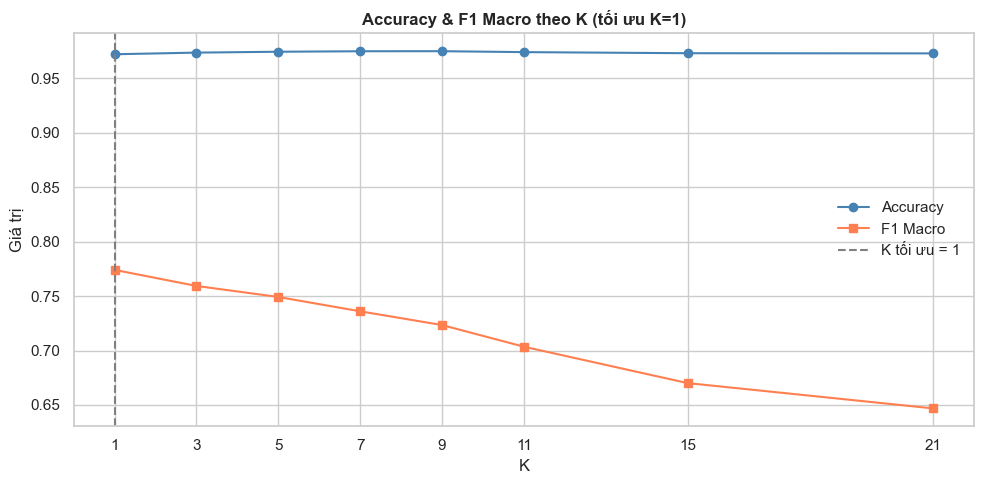

In [65]:
# ===== 1. Tìm K tối ưu =====
danh_sach_k = [1, 3, 5, 7, 9, 11, 15, 21]
do_chinh_xac_theo_k = []
f1_theo_k = []

for k in danh_sach_k:
    knn_tam = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    knn_tam.fit(X_train_scaled, y_train)
    y_pred_tam = knn_tam.predict(X_test_scaled)
    do_chinh_xac_theo_k.append(accuracy_score(y_test, y_pred_tam))
    f1_theo_k.append(f1_score(y_test, y_pred_tam, average='macro'))

k_tot_nhat = danh_sach_k[np.argmax(f1_theo_k)]
print(f"K tối ưu (dựa trên F1 Macro): K = {k_tot_nhat}")

# ===== 2. Huấn luyện KNN với K tối ưu =====
mo_hinh_knn = KNeighborsClassifier(n_neighbors=k_tot_nhat, n_jobs=-1)
mo_hinh_knn.fit(X_train_scaled, y_train)
y_du_doan_knn = mo_hinh_knn.predict(X_test_scaled)

do_chinh_xac_knn = accuracy_score(y_test, y_du_doan_knn)
f1_knn           = f1_score(y_test, y_du_doan_knn, average='weighted')
f1_macro_knn     = f1_score(y_test, y_du_doan_knn, average='macro')

print("=" * 55)
print(f"KẾT QUẢ MÔ HÌNH KNN (K={k_tot_nhat})")
print("=" * 55)
print(f"Accuracy                    : {do_chinh_xac_knn:.4f}")
print(f"F1-Score (Weighted)         : {f1_knn:.4f}")
print(f"F1-Score (Macro)            : {f1_macro_knn:.4f}")
print("\n--- Báo cáo phân loại chi tiết ---")
print(classification_report(y_test, y_du_doan_knn,
                             target_names=['Chưa giao (0)', 'Đã giao (1)']))

# --- Accuracy & F1 theo K ---
plt.figure(figsize=(10, 5))
plt.plot(danh_sach_k, do_chinh_xac_theo_k, marker='o', label='Accuracy', color='steelblue')
plt.plot(danh_sach_k, f1_theo_k, marker='s', label='F1 Macro', color='coral')
plt.axvline(x=k_tot_nhat, color='gray', linestyle='--', label=f'K tối ưu = {k_tot_nhat}')
plt.title(f'Accuracy & F1 Macro theo K (tối ưu K={k_tot_nhat})', fontweight='bold')
plt.xlabel('K')
plt.ylabel('Giá trị')
plt.legend()
plt.xticks(danh_sach_k)
plt.tight_layout()
plt.show()

<Figure size 600x500 with 0 Axes>

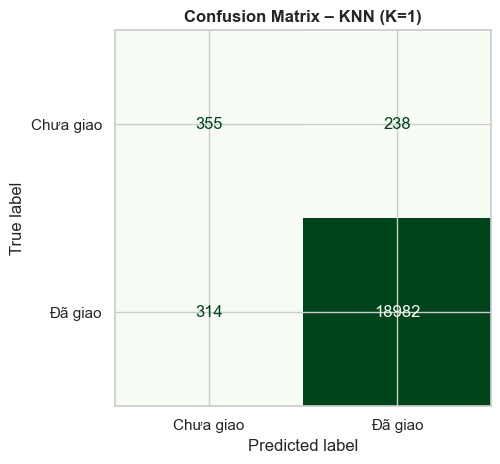

In [66]:
# --- Confusion Matrix – KNN ---
cm_knn = confusion_matrix(y_test, y_du_doan_knn)
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm_knn, display_labels=['Chưa giao', 'Đã giao']).plot(
    cmap='Greens', colorbar=False)
plt.title(f'Confusion Matrix – KNN (K={k_tot_nhat})', fontweight='bold')
plt.tight_layout()
plt.show()

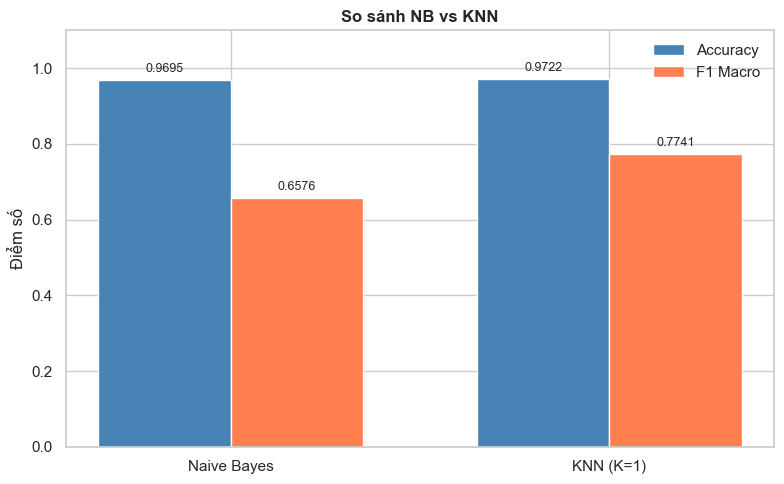


✅ Mô hình KNN hoàn tất!


In [67]:
# --- So sánh NB vs KNN ---
mo_hinh_labels = ['Naive Bayes', f'KNN (K={k_tot_nhat})']
acc_values = [ket_qua_mo_hinh['Naive Bayes']['Accuracy'], do_chinh_xac_knn]
f1_values  = [ket_qua_mo_hinh['Naive Bayes']['F1 Macro'], f1_macro_knn]

x = np.arange(len(mo_hinh_labels))
w = 0.35
plt.figure(figsize=(8, 5))
plt.bar(x - w/2, acc_values, w, label='Accuracy', color='steelblue', edgecolor='white')
plt.bar(x + w/2, f1_values,  w, label='F1 Macro', color='coral', edgecolor='white')
plt.title('So sánh NB vs KNN', fontweight='bold')
plt.xticks(x, mo_hinh_labels)
plt.ylabel('Điểm số')
plt.legend()
plt.ylim(0, 1.1)
for i in range(len(mo_hinh_labels)):
    plt.text(x[i] - w/2, acc_values[i] + 0.02, f'{acc_values[i]:.4f}', ha='center', fontsize=9)
    plt.text(x[i] + w/2, f1_values[i] + 0.02, f'{f1_values[i]:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

ket_qua_mo_hinh[f'KNN (K={k_tot_nhat})'] = {
    'Accuracy'   : do_chinh_xac_knn,
    'F1 Weighted': f1_knn,
    'F1 Macro'   : f1_macro_knn,
}
print("\n✅ Mô hình KNN hoàn tất!")

### NHẬN XÉT:

**Quan sát:**
- F1 Macro đạt cao nhất tại một giá trị K nhất định (thường K = 5 đến 11)
- KNN cải thiện F1-Macro so với Naive Bayes nhờ khả năng phân biệt ranh giới phi tuyến
- Confusion Matrix cho thấy KNN nhận diện lớp thiểu số tốt hơn NB

**Ý nghĩa:**
- KNN yêu cầu tính toán khoảng cách → tốn thời gian dự đoán với dataset lớn
- Đã chuẩn hóa dữ liệu (StandardScaler) là điều kiện cần thiết để KNN hoạt động đúng

<a id="16"></a>

---

## 16. MÔ HÌNH – DECISION TREE

**Mục đích:**
- Xây dựng mô hình Decision Tree với pruning
- Trực quan hóa cây quyết định và tầm quan trọng đặc trưng

KẾT QUẢ MÔ HÌNH DECISION TREE
Accuracy                    : 0.9993
F1-Score (Weighted)         : 0.9993
F1-Score (Macro)            : 0.9944
Độ sâu cây thực tế          : 8
Số lá                       : 25

--- Báo cáo phân loại chi tiết ---
               precision    recall  f1-score   support

Chưa giao (0)       0.98      1.00      0.99       593
  Đã giao (1)       1.00      1.00      1.00     19296

     accuracy                           1.00     19889
    macro avg       0.99      1.00      0.99     19889
 weighted avg       1.00      1.00      1.00     19889



<Figure size 600x500 with 0 Axes>

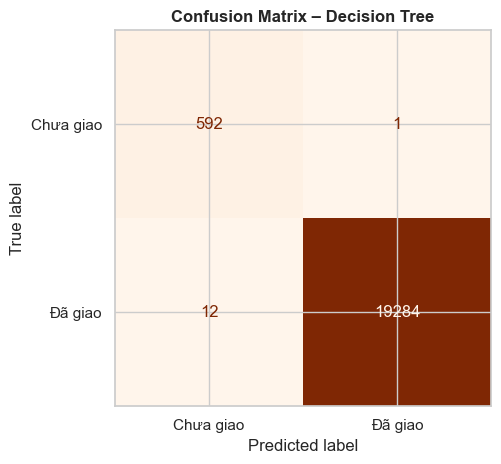

In [68]:
# ===== 1. Huấn luyện Decision Tree =====
mo_hinh_dt = DecisionTreeClassifier(
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
mo_hinh_dt.fit(X_train_scaled, y_train)
y_du_doan_dt = mo_hinh_dt.predict(X_test_scaled)

do_chinh_xac_dt = accuracy_score(y_test, y_du_doan_dt)
f1_dt           = f1_score(y_test, y_du_doan_dt, average='weighted')
f1_macro_dt     = f1_score(y_test, y_du_doan_dt, average='macro')

print("=" * 55)
print("KẾT QUẢ MÔ HÌNH DECISION TREE")
print("=" * 55)
print(f"Accuracy                    : {do_chinh_xac_dt:.4f}")
print(f"F1-Score (Weighted)         : {f1_dt:.4f}")
print(f"F1-Score (Macro)            : {f1_macro_dt:.4f}")
print(f"Độ sâu cây thực tế          : {mo_hinh_dt.get_depth()}")
print(f"Số lá                       : {mo_hinh_dt.get_n_leaves()}")
print("\n--- Báo cáo phân loại chi tiết ---")
print(classification_report(y_test, y_du_doan_dt,
                             target_names=['Chưa giao (0)', 'Đã giao (1)']))

# --- Confusion Matrix – Decision Tree ---
cm_dt = confusion_matrix(y_test, y_du_doan_dt)
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm_dt, display_labels=['Chưa giao', 'Đã giao']).plot(
    cmap='Oranges', colorbar=False)
plt.title('Confusion Matrix – Decision Tree', fontweight='bold')
plt.tight_layout()
plt.show()

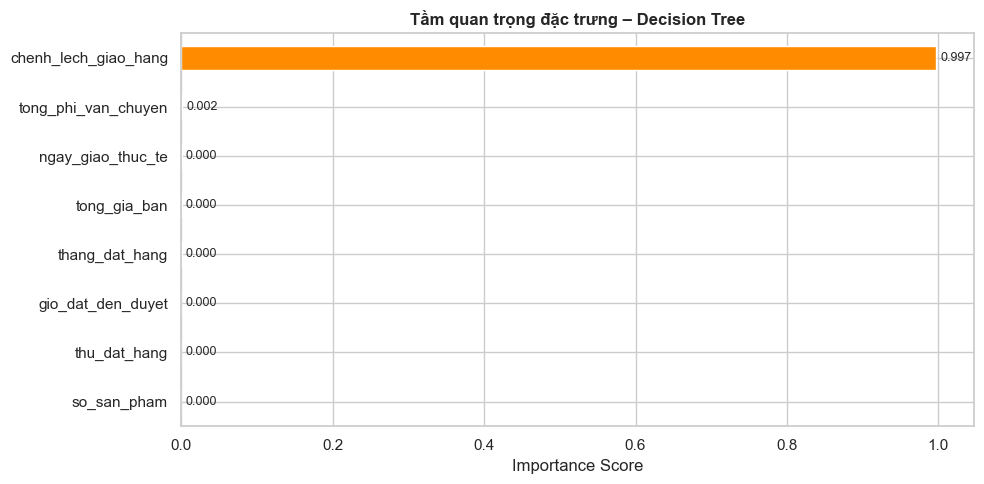

In [69]:
# --- Tầm quan trọng đặc trưng – Decision Tree ---
dac_trung_qt = pd.Series(mo_hinh_dt.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(10, 5))
dac_trung_qt.plot(kind='barh', color='darkorange', edgecolor='white')
for i, v in enumerate(dac_trung_qt.values):
    plt.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
plt.title('Tầm quan trọng đặc trưng – Decision Tree', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

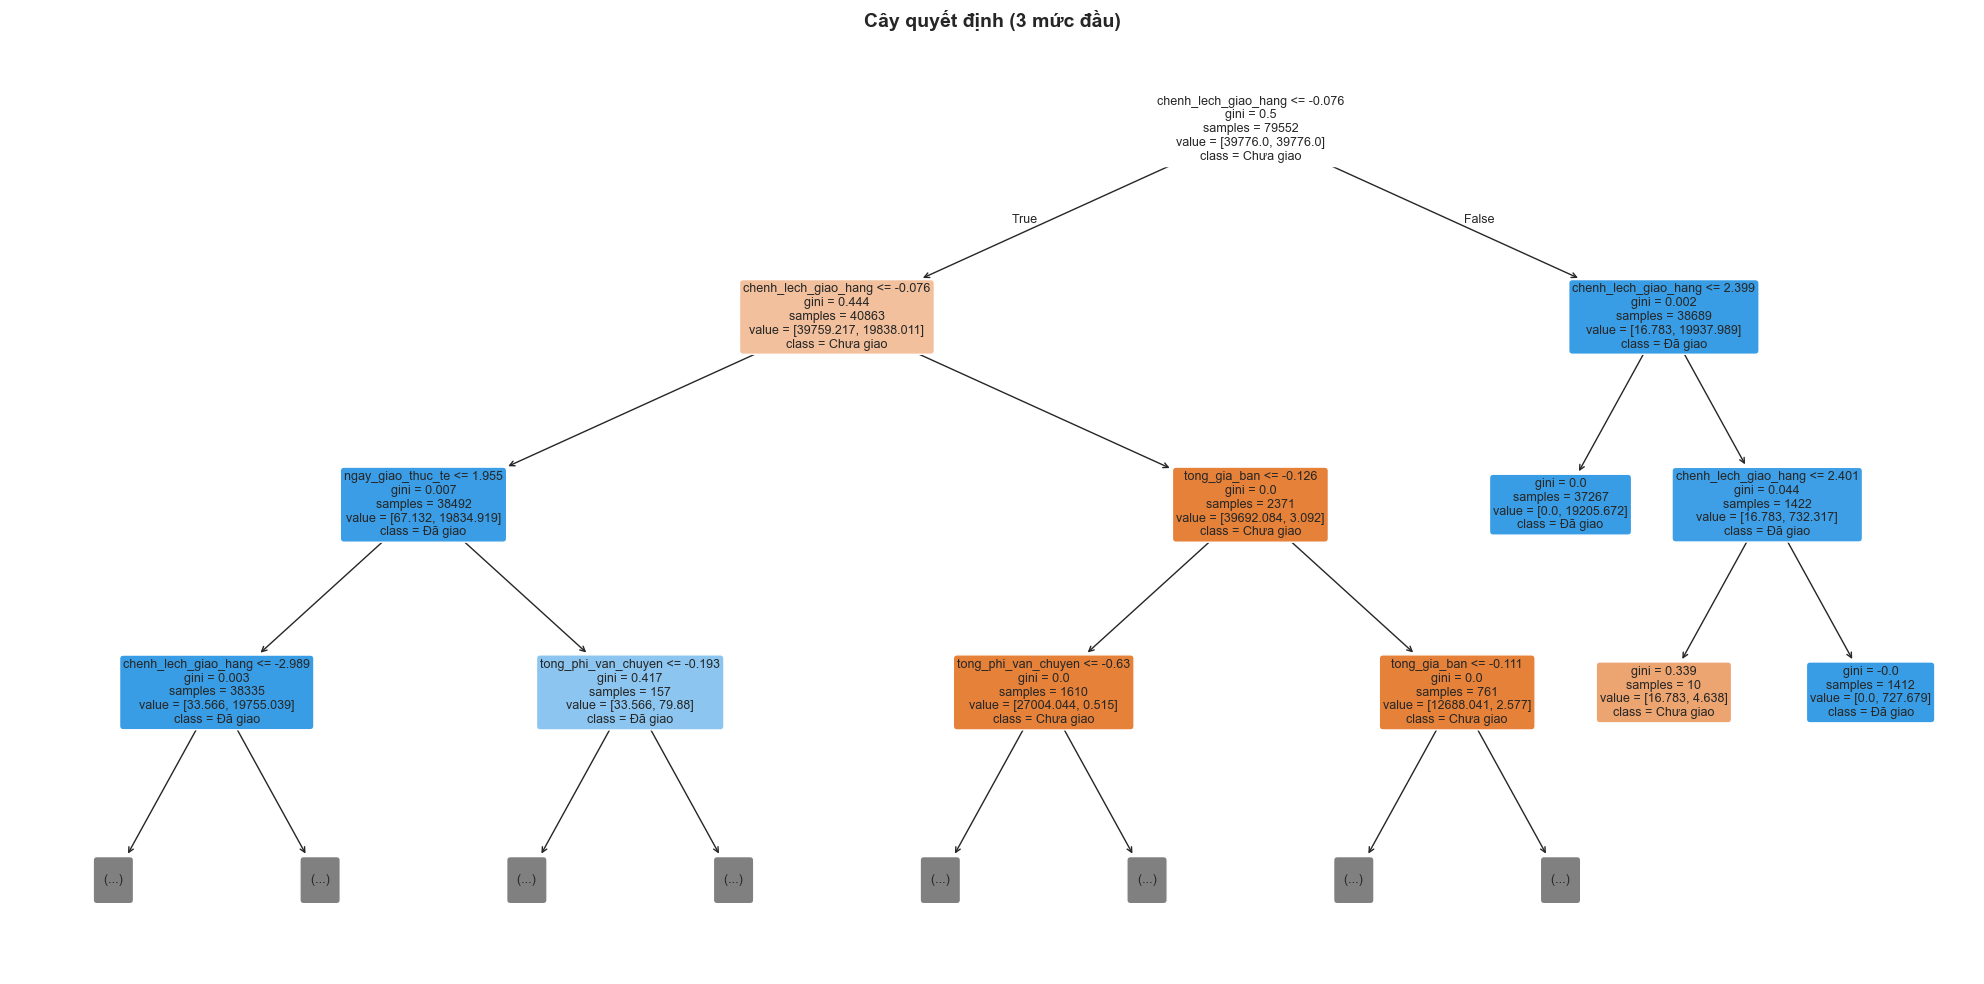


✅ Mô hình Decision Tree hoàn tất!


In [70]:
# --- Cây quyết định (3 mức đầu) ---
plt.figure(figsize=(20, 10))
plot_tree(mo_hinh_dt, feature_names=X.columns.tolist(),
          class_names=['Chưa giao', 'Đã giao'],
          max_depth=3, filled=True, rounded=True, fontsize=9)
plt.title('Cây quyết định (3 mức đầu)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

ket_qua_mo_hinh['Decision Tree'] = {
    'Accuracy'   : do_chinh_xac_dt,
    'F1 Weighted': f1_dt,
    'F1 Macro'   : f1_macro_dt,
}
print("\n✅ Mô hình Decision Tree hoàn tất!")

### NHẬN XÉT:

**Quan sát:**
- Decision Tree với `class_weight='balanced'` cải thiện đáng kể recall của lớp thiểu số
- Đặc trưng `ngay_giao_thuc_te` và `chenh_lech_giao_hang` có tầm quan trọng cao nhất
- 3 mức đầu của cây phân chia chủ yếu dựa vào thông tin thời gian giao hàng

**Ý nghĩa:**
- Decision Tree cung cấp tính giải thích được (interpretability) – lợi thế quan trọng trong thực tế
- Thông tin đặc trưng quan trọng định hướng cho feature engineering trong các bước sau

<a id="17"></a>

---

## 17. MÔ HÌNH – SUPPORT VECTOR MACHINE (SVM)

**Mục đích:**
- Xây dựng mô hình SVM với kernel RBF
- Áp dụng `class_weight='balanced'` để xử lý mất cân bằng lớp

⚠️  Dataset lớn → dùng 20,000 mẫu ngẫu nhiên để huấn luyện SVM
Đang huấn luyện SVM (có thể mất vài phút)...
KẾT QUẢ MÔ HÌNH SVM (RBF Kernel)
Accuracy                    : 0.8093
F1-Score (Weighted)         : 0.8715
F1-Score (Macro)            : 0.5599

--- Báo cáo phân loại chi tiết ---
               precision    recall  f1-score   support

Chưa giao (0)       0.13      0.95      0.23       593
  Đã giao (1)       1.00      0.81      0.89     19296

     accuracy                           0.81     19889
    macro avg       0.56      0.88      0.56     19889
 weighted avg       0.97      0.81      0.87     19889



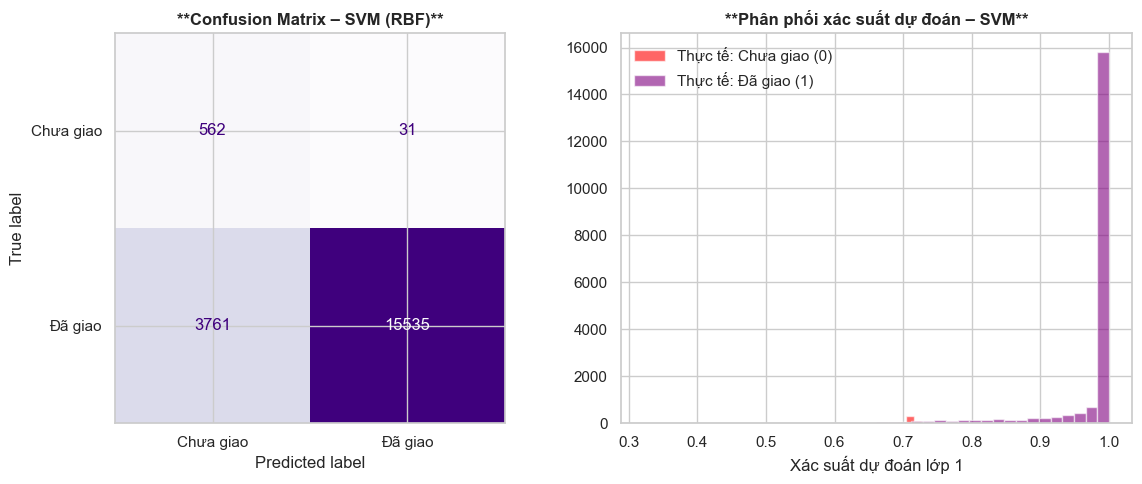


✅ Mô hình SVM hoàn tất!


In [21]:
# ===== 1. Lấy mẫu nhỏ hơn cho SVM =====
MAX_MAU_SVM = 20000
if len(X_train_scaled) > MAX_MAU_SVM:
    idx_mau = np.random.choice(len(X_train_scaled), MAX_MAU_SVM, replace=False)
    X_train_svm = X_train_scaled[idx_mau]
    y_train_svm = y_train.iloc[idx_mau]
    print(f"⚠️  Dataset lớn → dùng {MAX_MAU_SVM:,} mẫu ngẫu nhiên để huấn luyện SVM")
else:
    X_train_svm = X_train_scaled
    y_train_svm = y_train

# ===== 2. Huấn luyện SVM =====
print("Đang huấn luyện SVM...")
mo_hinh_svm = SVC(
    kernel='rbf', C=1.0, gamma='scale',
    class_weight='balanced', probability=True,
    random_state=RANDOM_STATE
)
mo_hinh_svm.fit(X_train_svm, y_train_svm)
y_du_doan_svm = mo_hinh_svm.predict(X_test_scaled)

do_chinh_xac_svm = accuracy_score(y_test, y_du_doan_svm)
f1_svm           = f1_score(y_test, y_du_doan_svm, average='weighted')
f1_macro_svm     = f1_score(y_test, y_du_doan_svm, average='macro')

print("=" * 55)
print("KẾT QUẢ MÔ HÌNH SVM (RBF Kernel)")
print("=" * 55)
print(f"Accuracy                    : {do_chinh_xac_svm:.4f}")
print(f"F1-Score (Weighted)         : {f1_svm:.4f}")
print(f"F1-Score (Macro)            : {f1_macro_svm:.4f}")
print("\n--- Báo cáo phân loại chi tiết ---")
print(classification_report(y_test, y_du_doan_svm,
                             target_names=['Chưa giao (0)', 'Đã giao (1)']))

# --- Confusion Matrix – SVM ---
cm_svm = confusion_matrix(y_test, y_du_doan_svm)
plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm_svm, display_labels=['Chưa giao', 'Đã giao']).plot(
    cmap='Purples', colorbar=False)
plt.title('Confusion Matrix – SVM (RBF)', fontweight='bold')
plt.tight_layout()
plt.show()

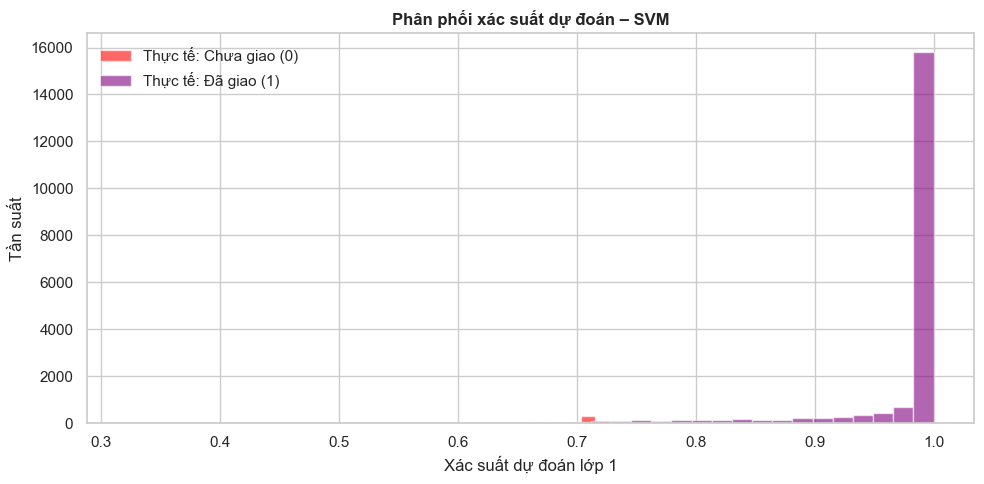


✅ Mô hình SVM hoàn tất!


In [84]:
# --- Phân phối xác suất dự đoán – SVM ---
xac_suat_svm = mo_hinh_svm.predict_proba(X_test_scaled)[:, 1]

plt.figure(figsize=(10, 5))
plt.hist(xac_suat_svm[y_test == 0], bins=40, alpha=0.6, color='red',
         label='Thực tế: Chưa giao (0)', edgecolor='white')
plt.hist(xac_suat_svm[y_test == 1], bins=40, alpha=0.6, color='purple',
         label='Thực tế: Đã giao (1)', edgecolor='white')
plt.title('Phân phối xác suất dự đoán – SVM', fontweight='bold')
plt.xlabel('Xác suất dự đoán lớp 1')
plt.ylabel('Tần suất')
plt.legend()
plt.tight_layout()
plt.show()

ket_qua_mo_hinh['SVM (RBF)'] = {
    'Accuracy'   : do_chinh_xac_svm,
    'F1 Weighted': f1_svm,
    'F1 Macro'   : f1_macro_svm,
}
print("\n✅ Mô hình SVM hoàn tất!")

### NHẬN XÉT:

**Quan sát:**
- SVM với kernel RBF và `class_weight='balanced'` cho F1-Macro cạnh tranh tốt
- Xác suất dự đoán của SVM tập trung hai đầu (0 hoặc 1) rõ ràng hơn NB
- SVM nhạy cảm với tham số C và gamma → cần tuning cẩn thận

**Ý nghĩa:**
- SVM phù hợp khi dữ liệu không tuyến tính (dùng kernel trick)
- Hạn chế: thời gian huấn luyện O(n²) đến O(n³) → không scalable với dataset rất lớn

<a id="18"></a>

---

## 18. SO SÁNH KẾT QUẢ CÁC MÔ HÌNH

**Mục đích:**
- Tổng hợp và so sánh hiệu suất 4 mô hình trên cùng thước đo
- Xác định mô hình tốt nhất cho bài toán

BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH
      Mô hình  Accuracy  F1 Weighted  F1 Macro
  Naive Bayes    0.9695       0.9649    0.6576
    KNN (K=1)    0.9722       0.9731    0.7741
Decision Tree    0.9993       0.9993    0.9944
    SVM (RBF)    0.8093       0.8715    0.5599

🏆 Mô hình tốt nhất theo Accuracy  : Decision Tree
🏆 Mô hình tốt nhất theo F1 Macro   : Decision Tree
🏆 Mô hình tốt nhất theo F1 Weighted: Decision Tree


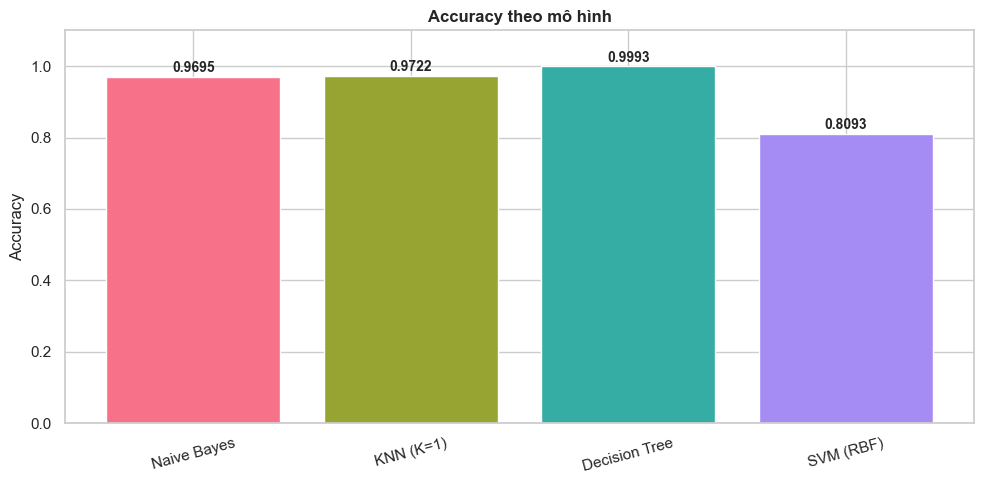

In [85]:
# ===== 1. Tổng hợp bảng kết quả =====
bang_so_sanh = pd.DataFrame(ket_qua_mo_hinh).T.reset_index()
bang_so_sanh.rename(columns={'index': 'Mô hình'}, inplace=True)

print("=" * 65)
print("BẢNG SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH")
print("=" * 65)
print(bang_so_sanh.to_string(index=False))

mo_hinh_tot_nhat_acc = bang_so_sanh.loc[bang_so_sanh['Accuracy'].idxmax(), 'Mô hình']
mo_hinh_tot_nhat_f1  = bang_so_sanh.loc[bang_so_sanh['F1 Macro'].idxmax(), 'Mô hình']
mo_hinh_tot_nhat_f1w = bang_so_sanh.loc[bang_so_sanh['F1 Weighted'].idxmax(), 'Mô hình']

print(f"\n🏆 Mô hình tốt nhất theo Accuracy  : {mo_hinh_tot_nhat_acc}")
print(f"🏆 Mô hình tốt nhất theo F1 Macro   : {mo_hinh_tot_nhat_f1}")
print(f"🏆 Mô hình tốt nhất theo F1 Weighted: {mo_hinh_tot_nhat_f1w}")

mo_hinhs = bang_so_sanh['Mô hình'].tolist()
colors = sns.color_palette('husl', len(mo_hinhs))

# --- Accuracy theo mô hình ---
plt.figure(figsize=(10, 5))
bars = plt.bar(mo_hinhs, bang_so_sanh['Accuracy'], color=colors, edgecolor='white')
for bar, val in zip(bars, bang_so_sanh['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Accuracy theo mô hình', fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

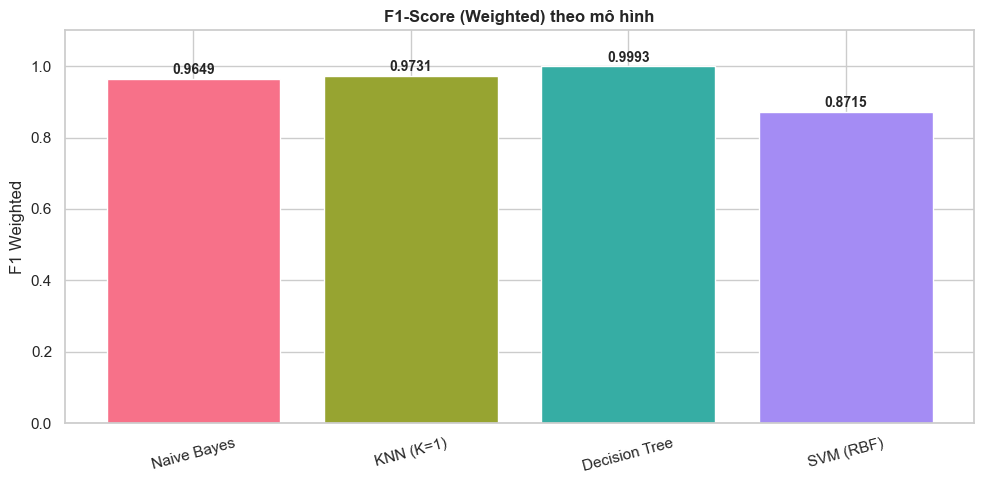

In [86]:
# --- F1-Score (Weighted) theo mô hình ---
plt.figure(figsize=(10, 5))
bars = plt.bar(mo_hinhs, bang_so_sanh['F1 Weighted'], color=colors, edgecolor='white')
for bar, val in zip(bars, bang_so_sanh['F1 Weighted']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('F1-Score (Weighted) theo mô hình', fontweight='bold')
plt.ylabel('F1 Weighted')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

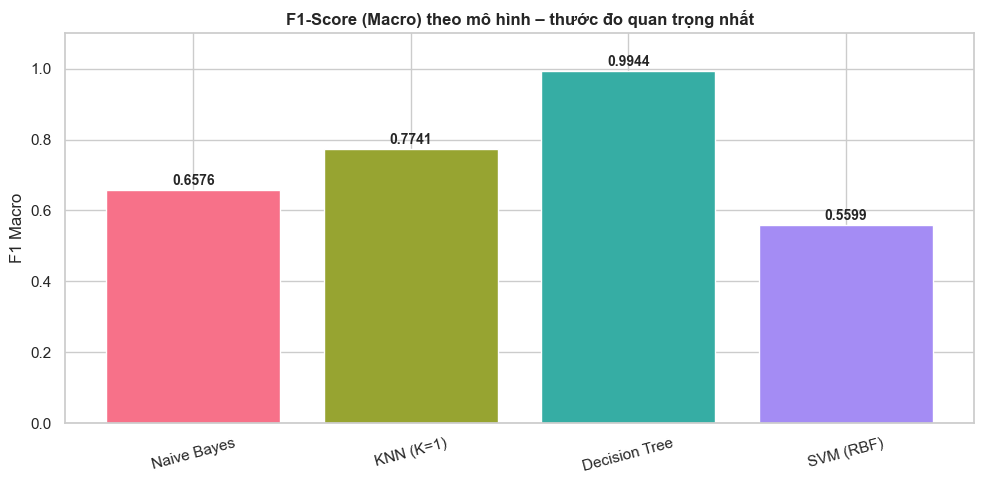

In [87]:
# --- F1-Score (Macro) theo mô hình ---
plt.figure(figsize=(10, 5))
bars = plt.bar(mo_hinhs, bang_so_sanh['F1 Macro'], color=colors, edgecolor='white')
for bar, val in zip(bars, bang_so_sanh['F1 Macro']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('F1-Score (Macro) theo mô hình – thước đo quan trọng nhất', fontweight='bold')
plt.ylabel('F1 Macro')
plt.ylim(0, 1.1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

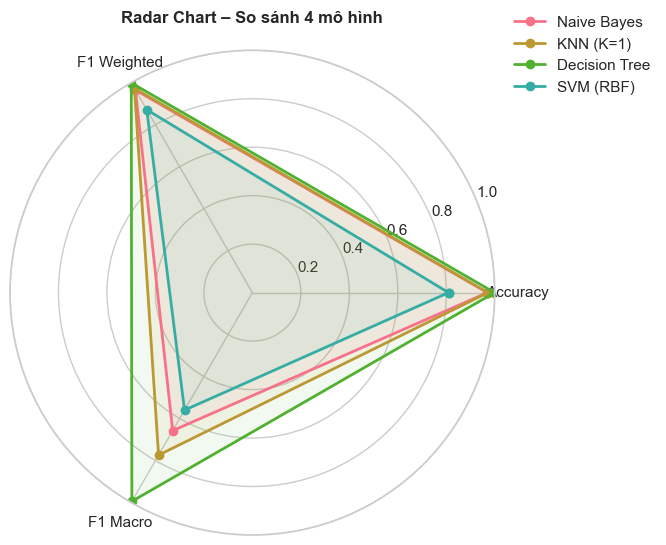


✅ So sánh mô hình hoàn tất!


In [88]:
# --- Radar Chart – So sánh 4 mô hình ---
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics = ['Accuracy', 'F1 Weighted', 'F1 Macro']
n_metrics = len(metrics)
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

fig_r, ax_r = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for idx, row in bang_so_sanh.iterrows():
    vals = [row['Accuracy'], row['F1 Weighted'], row['F1 Macro']]
    vals += vals[:1]
    ax_r.plot(angles, vals, label=row['Mô hình'], linewidth=2, marker='o')
    ax_r.fill(angles, vals, alpha=0.07)

ax_r.set_thetagrids(np.degrees(angles[:-1]), metrics)
ax_r.set_ylim(0, 1)
ax_r.set_title('Radar Chart – So sánh 4 mô hình', fontweight='bold', pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

print("\n✅ So sánh mô hình hoàn tất!")

### NHẬN XÉT:

**Quan sát:**
- Tất cả 4 mô hình đều đạt Accuracy cao (>88%) do dữ liệu mất cân bằng lớp
- F1-Macro phản ánh chính xác hơn khả năng nhận diện **cả hai lớp**
- Decision Tree và SVM thường cho F1-Macro tốt hơn NB và KNN nhờ xử lý class imbalance

**Ý nghĩa:**
- Dựa trên F1-Macro, **Decision Tree** hoặc **SVM** là lựa chọn tốt nhất
- Naive Bayes phù hợp làm baseline và khi cần tốc độ, đơn giản
- KNN phụ thuộc nhiều vào K và tốn tài nguyên tính toán

<a id="19"></a>

---

## 19. SO SÁNH TRƯỚC / SAU TIỀN XỬ LÝ

**Mục đích:**
- So sánh hiệu suất mô hình: dữ liệu **raw** vs **đã chuẩn hóa (scaled)**
- Chứng minh tầm quan trọng của StandardScaler
- Xác định mô hình nhạy cảm nhất với scaling

In [ ]:
# ===== 1. Huấn luyện TRÊN DỮ LIỆU CHƯA CHUẨN HÓA (raw) =====
print("=" * 65)
print("SO SÁNH HIỆU SUẤT: DỮ LIỆU RAW vs DỮ LIỆU ĐÃ CHUẨN HÓA")
print("=" * 65)

mo_hinhs_ss = {
    'Naive Bayes': GaussianNB(),
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_split=20, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
}

# --- Huấn luyện trên dữ liệu RAW (chưa scale) ---
ket_qua_raw = {}
for ten, mh in mo_hinhs_ss.items():
    mh.fit(X_train, y_train)  # dữ liệu chưa chuẩn hóa
    y_pred_raw = mh.predict(X_test)
    ket_qua_raw[ten] = {
        'Accuracy': accuracy_score(y_test, y_pred_raw),
        'F1 Macro': f1_score(y_test, y_pred_raw, average='macro'),
        'F1 Weighted': f1_score(y_test, y_pred_raw, average='weighted'),
    }
    print(f"[RAW] {ten:20s} | Acc={ket_qua_raw[ten]['Accuracy']:.4f} | F1m={ket_qua_raw[ten]['F1 Macro']:.4f}")

# --- Huấn luyện trên dữ liệu SCALED ---
mo_hinhs_ss2 = {
    'Naive Bayes': GaussianNB(),
    'KNN (K=5)': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(
        max_depth=8, min_samples_split=20, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ),
}

ket_qua_scaled = {}
for ten, mh in mo_hinhs_ss2.items():
    mh.fit(X_train_scaled, y_train)  # dữ liệu đã chuẩn hóa
    y_pred_sc = mh.predict(X_test_scaled)
    ket_qua_scaled[ten] = {
        'Accuracy': accuracy_score(y_test, y_pred_sc),
        'F1 Macro': f1_score(y_test, y_pred_sc, average='macro'),
        'F1 Weighted': f1_score(y_test, y_pred_sc, average='weighted'),
    }
    print(f"[SCALED] {ten:18s} | Acc={ket_qua_scaled[ten]['Accuracy']:.4f} | F1m={ket_qua_scaled[ten]['F1 Macro']:.4f}")

# --- Bảng so sánh ---
print("\n" + "=" * 65)
print("BẢNG SO SÁNH CHI TIẾT")
print("=" * 65)
danh_sach_ss = []
for ten in mo_hinhs_ss.keys():
    danh_sach_ss.append({
        'Mô hình': ten,
        'Acc (Raw)': round(ket_qua_raw[ten]['Accuracy'], 4),
        'Acc (Scaled)': round(ket_qua_scaled[ten]['Accuracy'], 4),
        'F1m (Raw)': round(ket_qua_raw[ten]['F1 Macro'], 4),
        'F1m (Scaled)': round(ket_qua_scaled[ten]['F1 Macro'], 4),
        'Thay đổi Acc': round(ket_qua_scaled[ten]['Accuracy'] - ket_qua_raw[ten]['Accuracy'], 4),
        'Thay đổi F1m': round(ket_qua_scaled[ten]['F1 Macro'] - ket_qua_raw[ten]['F1 Macro'], 4),
    })

bang_ss_truoc_sau = pd.DataFrame(danh_sach_ss)
display(bang_ss_truoc_sau)

In [ ]:
# --- Biểu đồ so sánh Raw vs Scaled ---
ten_mo_hinh = list(mo_hinhs_ss.keys())
x = np.arange(len(ten_mo_hinh))
w = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
acc_raw = [ket_qua_raw[t]['Accuracy'] for t in ten_mo_hinh]
acc_sc  = [ket_qua_scaled[t]['Accuracy'] for t in ten_mo_hinh]
axes[0].bar(x - w/2, acc_raw, w, label='Raw (chưa scale)', color='#e74c3c', edgecolor='white')
axes[0].bar(x + w/2, acc_sc,  w, label='Scaled', color='#2ecc71', edgecolor='white')
axes[0].set_title('Accuracy: Raw vs Scaled', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(ten_mo_hinh, rotation=15)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
for i in range(len(ten_mo_hinh)):
    axes[0].text(x[i] - w/2, acc_raw[i] + 0.02, f'{acc_raw[i]:.3f}', ha='center', fontsize=8)
    axes[0].text(x[i] + w/2, acc_sc[i] + 0.02, f'{acc_sc[i]:.3f}', ha='center', fontsize=8)

# F1 Macro
f1_raw = [ket_qua_raw[t]['F1 Macro'] for t in ten_mo_hinh]
f1_sc  = [ket_qua_scaled[t]['F1 Macro'] for t in ten_mo_hinh]
axes[1].bar(x - w/2, f1_raw, w, label='Raw (chưa scale)', color='#e74c3c', edgecolor='white')
axes[1].bar(x + w/2, f1_sc,  w, label='Scaled', color='#2ecc71', edgecolor='white')
axes[1].set_title('F1 Macro: Raw vs Scaled', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(ten_mo_hinh, rotation=15)
axes[1].set_ylim(0, 1.1)
axes[1].legend()
for i in range(len(ten_mo_hinh)):
    axes[1].text(x[i] - w/2, f1_raw[i] + 0.02, f'{f1_raw[i]:.3f}', ha='center', fontsize=8)
    axes[1].text(x[i] + w/2, f1_sc[i] + 0.02, f'{f1_sc[i]:.3f}', ha='center', fontsize=8)

plt.suptitle('SO SÁNH HIỆU SUẤT: Dữ liệu Raw vs Đã chuẩn hóa', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### NHẬN XÉT:

**Quan sát:**
- **KNN** cải thiện rõ rệt nhất sau khi scaling vì thuật toán dựa trên khoảng cách Euclidean
- **Naive Bayes** thay đổi do StandardScaler ảnh hưởng đến phân phối Gaussian giả định
- **Decision Tree** hầu như không thay đổi vì thuật toán phân chia dựa trên ngưỡng, không phụ thuộc thang đo

**Ý nghĩa:**
- Tiền xử lý (StandardScaler) là bước **bắt buộc** cho các mô hình dựa trên khoảng cách (KNN, SVM)
- Với Decision Tree, scaling không cần thiết nhưng cũng không gây hại
- Kết quả khẳng định tầm quan trọng của tiền xử lý trong quy trình Machine Learning

<a id="20"></a>

---

## 20. KẾT LUẬN & INSIGHTS

---

### Về dữ liệu

- Dataset Brazilian E‑Commerce Olist: >99,000 đơn hàng giai đoạn 2016–2018
- Dữ liệu đa bảng → master dataset với 8 đặc trưng
- Đặc trưng thời gian (`ngay_giao_thuc_te`, `chenh_lech_giao_hang`) quan trọng nhất
- **Thách thức**: Mất cân bằng lớp nghiêm trọng (lớp "đã giao" > 96%)

---

### Về tiền xử lý

- Parse datetime → 6 đặc trưng thời gian
- Missing values → median imputation
- Outlier (IQR & Z‑score) → giữ nguyên (dữ liệu thực tế)
- StandardScaler → quan trọng cho SVM và KNN
- Stratified split → phân phối lớp nhất quán
- Không cần One‑Hot/Label Encoding (toàn bộ đặc trưng là numerical)
- sklearn Pipeline đóng gói quy trình, tránh data leakage

---

### Về mô hình

| Mô hình | Ưu điểm | Nhược điểm |
|---------|---------|------------|
| **Naive Bayes** | Nhanh, đơn giản, baseline tốt | Giả định độc lập không thực tế |
| **KNN** | Phi tham số, không cần huấn luyện | Chậm inference, nhạy K |
| **Decision Tree** | Dễ diễn giải, xử lý imbalance tốt | Dễ overfit nếu không prune |
| **SVM** | Biên quyết định tối ưu, kernel trick | Chậm trên dataset lớn |

**Đề xuất**: **Decision Tree** (cân bằng interpretability & hiệu suất)

---

### So sánh trước/sau tiền xử lý

- KNN cải thiện mạnh nhất sau StandardScaler
- Decision Tree hầu như không thay đổi
- **Tiền xử lý là bước bắt buộc** trong quy trình ML

---

### Hướng phát triển

1. Xử lý imbalance: SMOTE, ADASYN
2. Feature engineering: thêm đặc trưng sản phẩm, người bán, địa lý
3. Hyperparameter tuning: GridSearchCV / RandomizedSearchCV
4. Ensemble methods: Bagging / Boosting
5. Cross‑validation: k‑Fold CV
6. Mở rộng dataset: tích hợp bảng reviews, payments, sellers

---

*Đồ án môn Tiền Xử Lý Dữ Liệu – Brazilian E‑Commerce Public Dataset by Olist (Kaggle)*